<a href="https://colab.research.google.com/github/juniperlovato/Taste_for_Privacy_Facct/blob/main/4_Taste4Privacy_instanddems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import numpy as np
import pandas as pd
import os
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.miscmodels.ordinal_model import OrderedModel

# Data

In [ ]:
# read in df_all
df_all = pd.read_csv('filepath.csv')

# Taste for privacy by context and demographics

In [ ]:
CONTEXTS = [
    "TP_Gov","TP_Police","TP_Friend","TP_Relative","TP_Employer","TP_Medical",
    "TP_Financial","TP_Neighbor","TP_Acquaintance","TP_Co_worker","TP_School",
    "TP_Researcher","TP_Platform","TP_NonProf","TP_Company_cust","TP_Company_notcust","TP_Stranger"
]
id_col = "ID"

#Is taste for privacy shaped by both who you are? does the prefence of contexts change by demographics?

#Mean difference bootstraps

In [ ]:
# Plot mean discomfort differences between two groups
# Positive = Group 1 MORE uncomfortable

def plot_mean_difference(df, contexts, demo_col1, demo_col2, group1_name, group2_name,
                        n_bootstrap=10000, save_path=None):

    df_g1 = df[df[demo_col1] == 1]
    df_g2 = df[df[demo_col2] == 1]

    # Bootstrap mean differences
    np.random.seed(42)
    mean_diffs = {ctx: [] for ctx in contexts}

    for i in range(n_bootstrap):
        boot_g1 = df_g1.sample(n=len(df_g1), replace=True)
        boot_g2 = df_g2.sample(n=len(df_g2), replace=True)

        for ctx in contexts:
            mean_g1 = boot_g1[ctx].mean()
            mean_g2 = boot_g2[ctx].mean()
            mean_diffs[ctx].append(mean_g1 - mean_g2)

    # Calculate statistics
    results = []
    for ctx in contexts:
        diffs = mean_diffs[ctx]
        results.append({
            'institution': ctx.replace('TP_', ''),
            'mean_diff': np.mean(diffs),
            'ci_lo': np.percentile(diffs, 2.5),
            'ci_hi': np.percentile(diffs, 97.5),
            'significant': not (np.percentile(diffs, 2.5) <= 0 <= np.percentile(diffs, 97.5)),
            'g1_mean': df_g1[ctx].mean(),
            'g2_mean': df_g2[ctx].mean()
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('mean_diff', key=abs, ascending=False)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    y_pos = np.arange(len(results_df))

    colors = ['steelblue' if sig else 'lightgray' for sig in results_df['significant']]
    ax.barh(y_pos, results_df['mean_diff'], color=colors, alpha=0.7)

    xerr = np.abs(results_df[['ci_lo', 'ci_hi']].values.T - results_df['mean_diff'].values)
    ax.errorbar(results_df['mean_diff'], y_pos, xerr=xerr,
                fmt='none', color='black', capsize=3, linewidth=1)

    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(results_df['institution'])
    ax.set_xlabel(f'Mean Discomfort Difference ({group1_name} - {group2_name})\nPositive = {group1_name} more uncomfortable')
    ax.set_ylabel('Institution')

    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Significant (95% CI excludes 0)'),
        Patch(facecolor='lightgray', alpha=0.7, label='Not significant')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()

    return fig, results_df

##gender

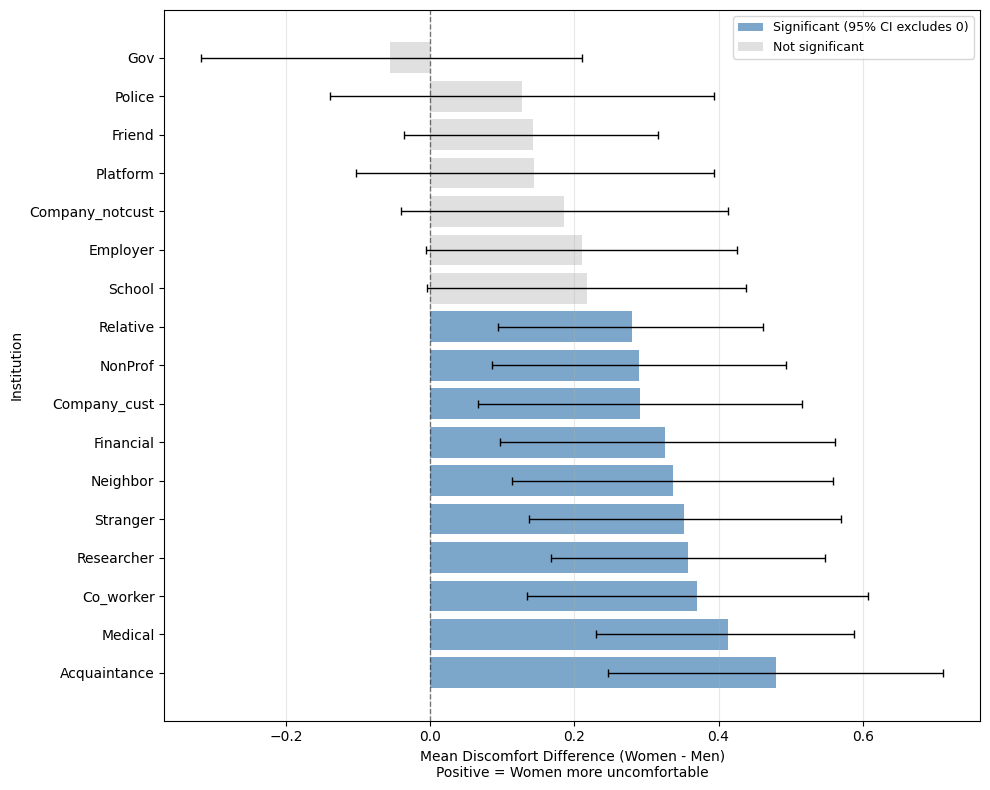

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Gender_Woman', 'Dem_Gender_Man',
    'Women', 'Men'
)

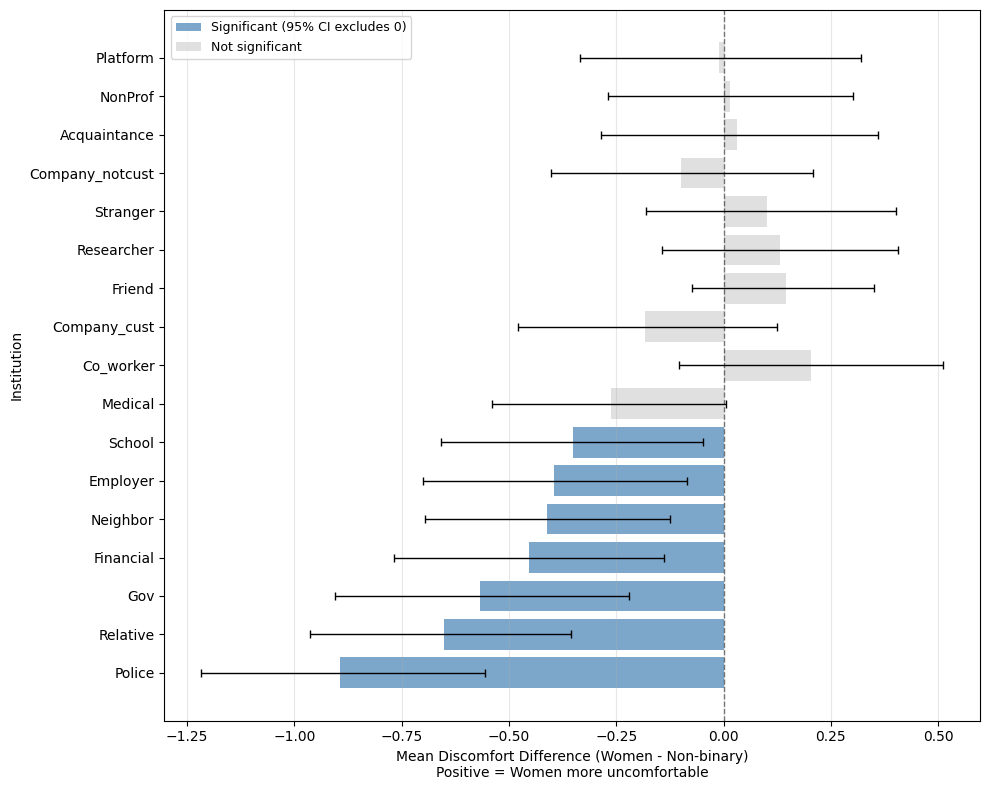

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Gender_Woman', 'Dem_Gender_Other',
    'Women', 'Non-binary'
)

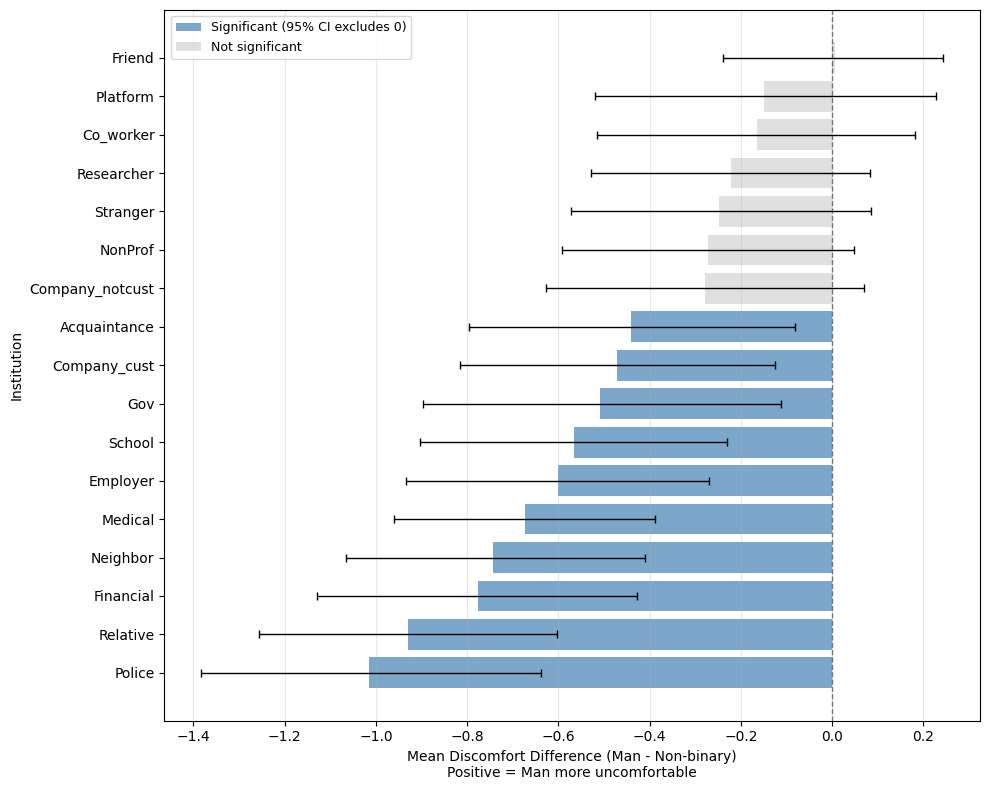

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Gender_Man', 'Dem_Gender_Other',
    'Man', 'Non-binary'
)

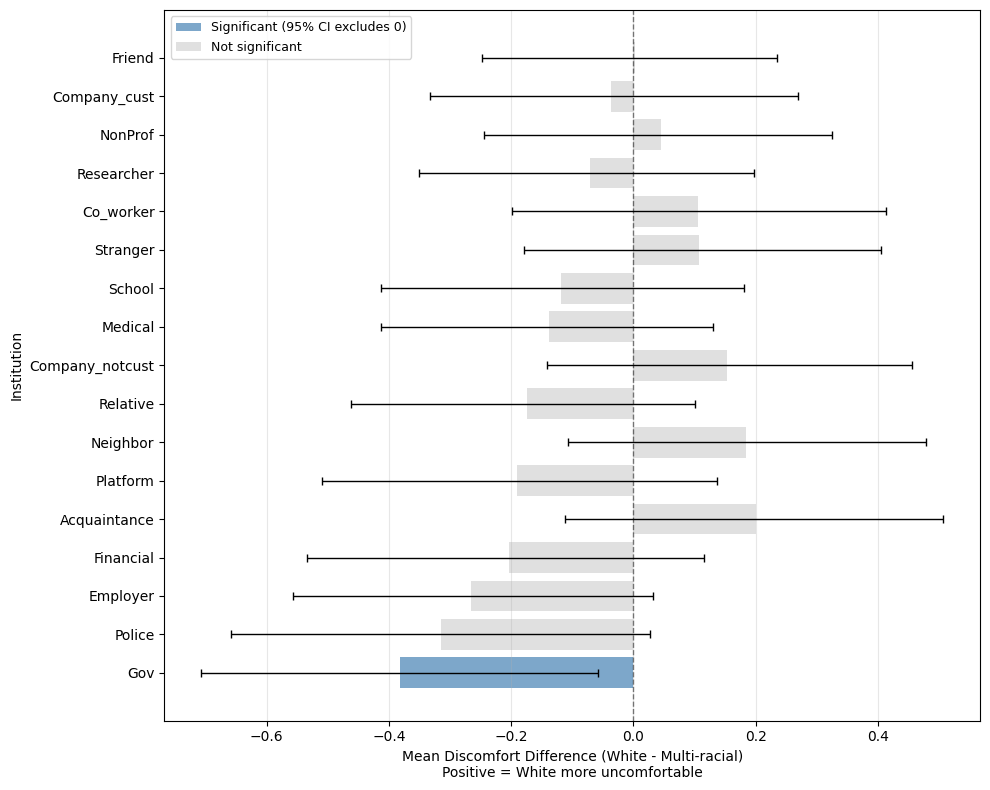

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Race_White', 'Dem_Race_Mixed',
    'White', 'Multi-racial'
)

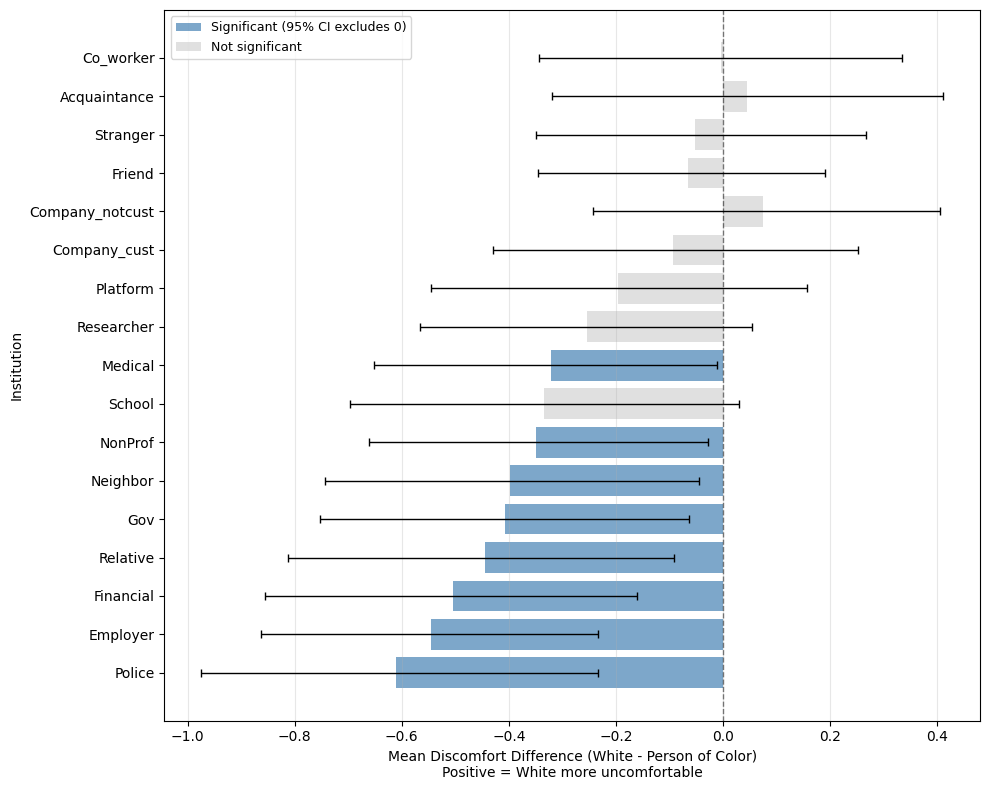

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Race_White', 'Dem_Race_POC',
    'White', 'Person of Color'
)

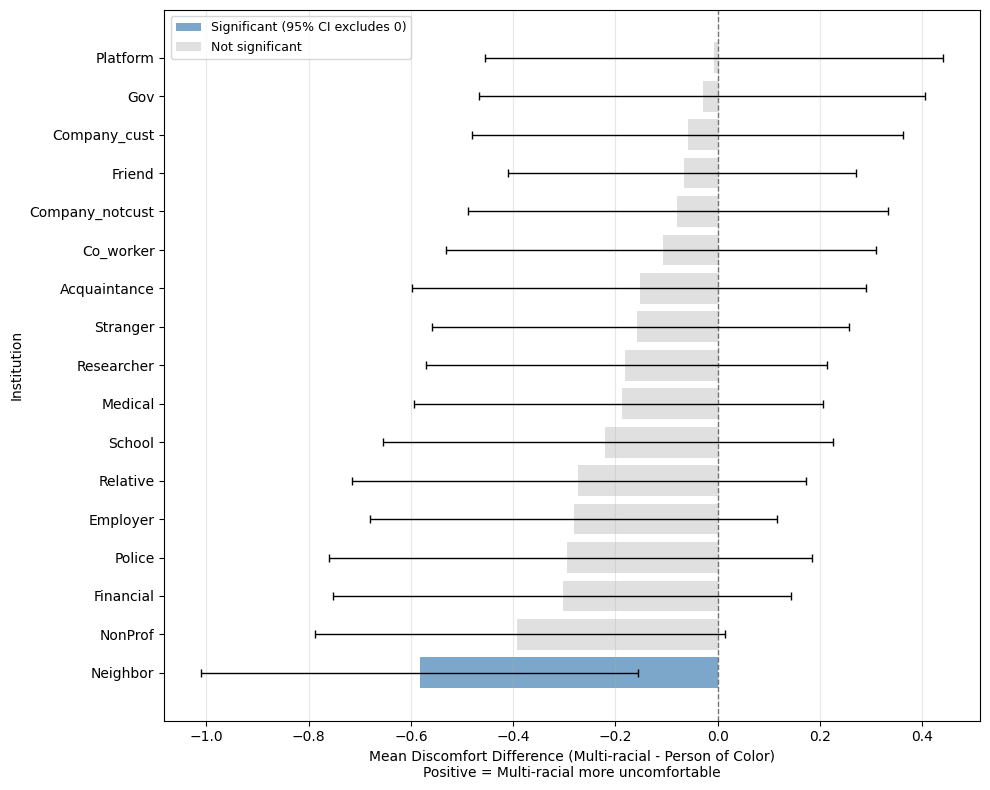

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Race_Mixed', 'Dem_Race_POC',
    'Multi-racial', 'Person of Color'
)

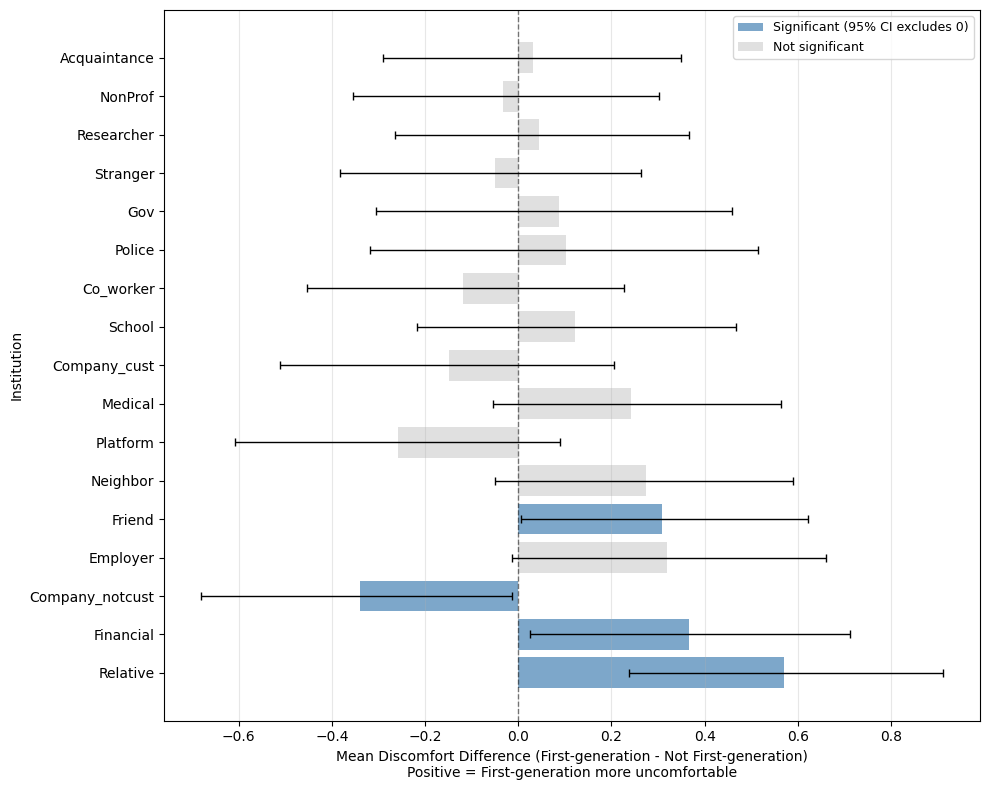

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_FirtsGen_Yes', 'Dem_FirtsGen_No',
    'First-generation', 'Not First-generation'
)

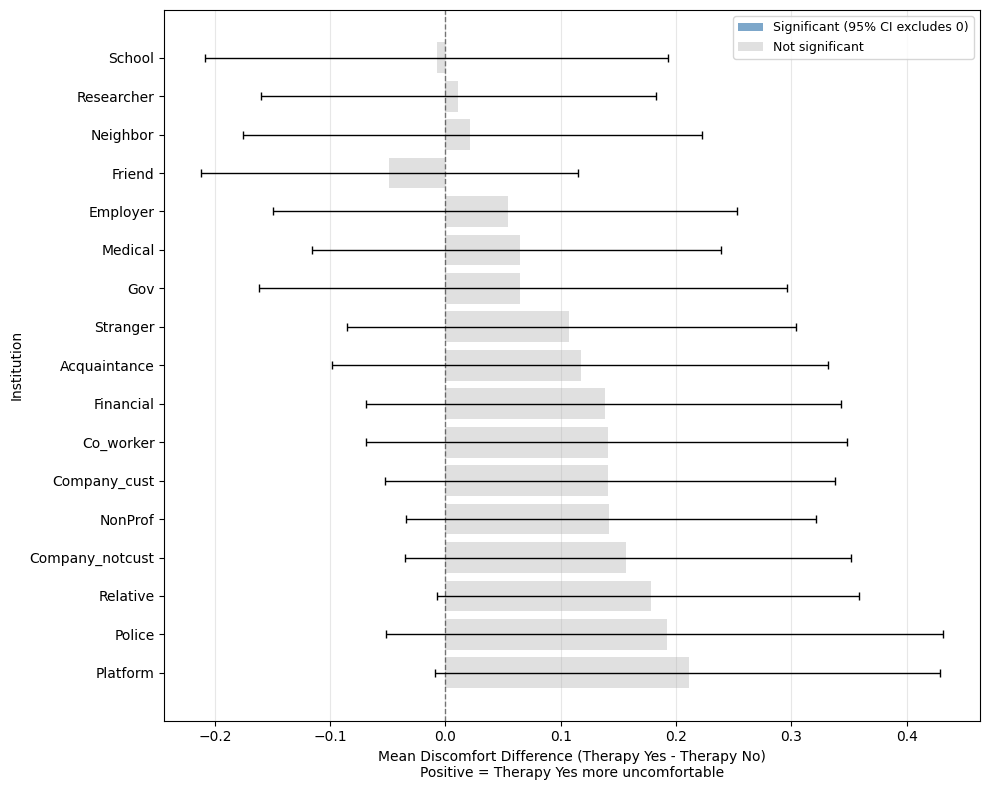

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Therapy_Yes', 'Dem_Therapy_No',
    'Therapy Yes', 'Therapy No'
)

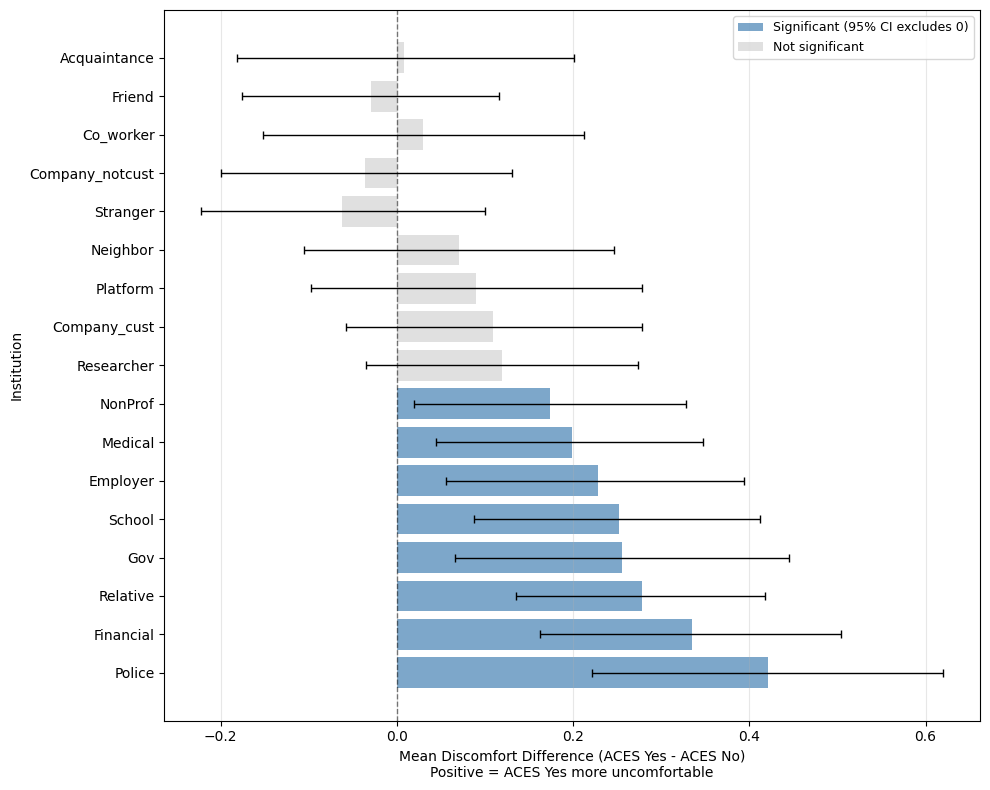

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'ACES_Yes', 'ACES_No',
    'ACES Yes', 'ACES No'
)

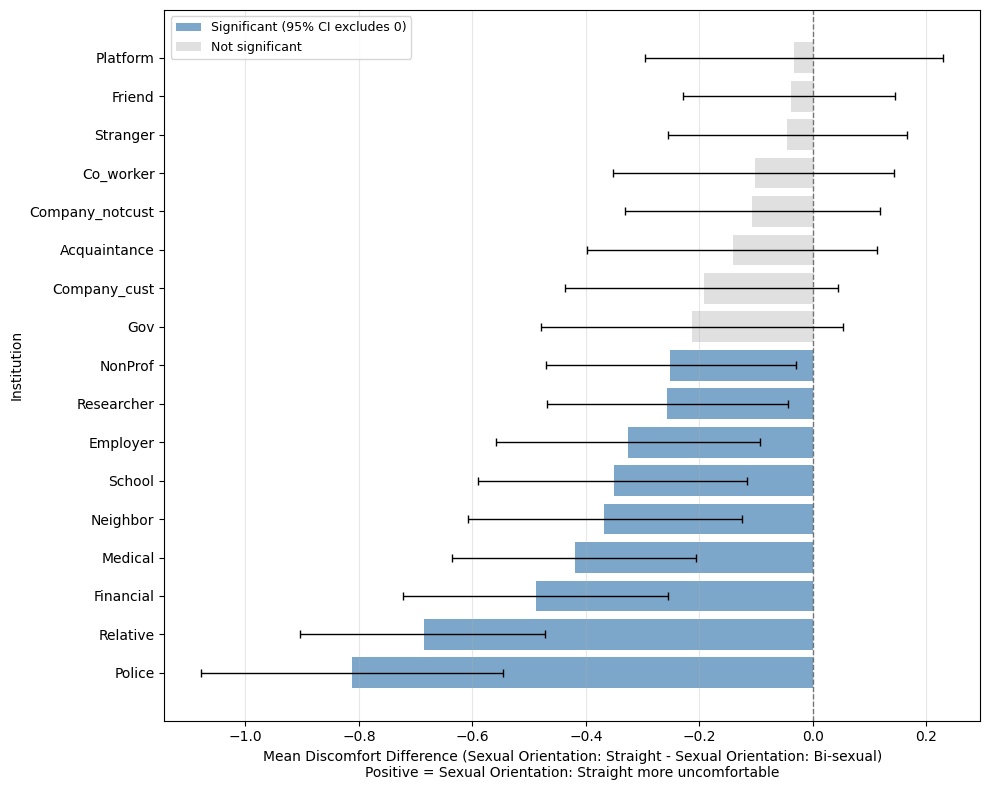

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Sexual_Orientation_straight', 'Dem_Sexual_Orientation_Bisexual',
    'Sexual Orientation: Straight', 'Sexual Orientation: Bi-sexual'
)

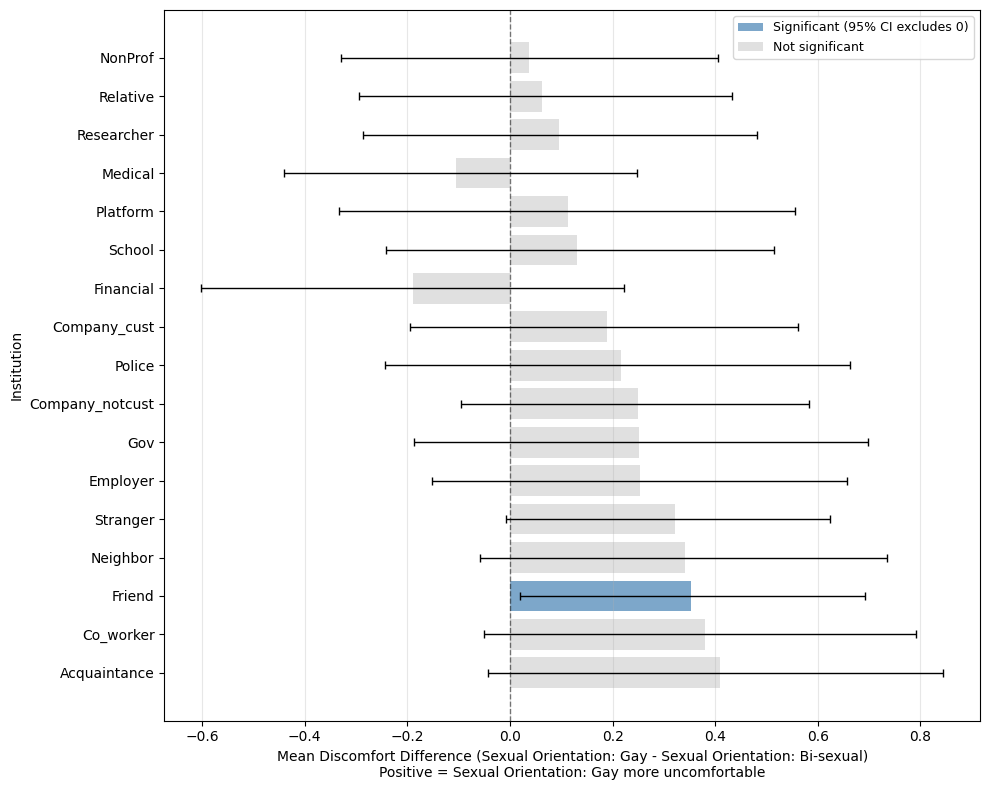

In [ ]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Sexual_Orientation_Gay', 'Dem_Sexual_Orientation_Bisexual',
    'Sexual Orientation: Gay', 'Sexual Orientation: Bi-sexual'
)

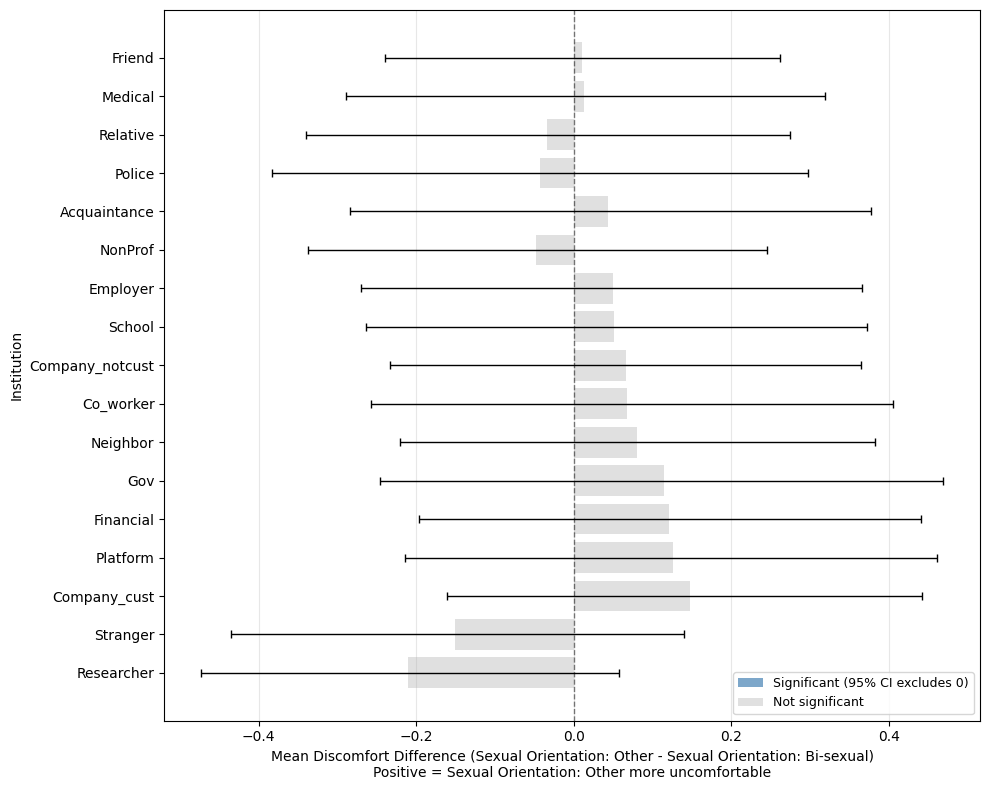

In [53]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Sexual_Orientation_other', 'Dem_Sexual_Orientation_Bisexual',
    'Sexual Orientation: Other', 'Sexual Orientation: Bi-sexual'
)

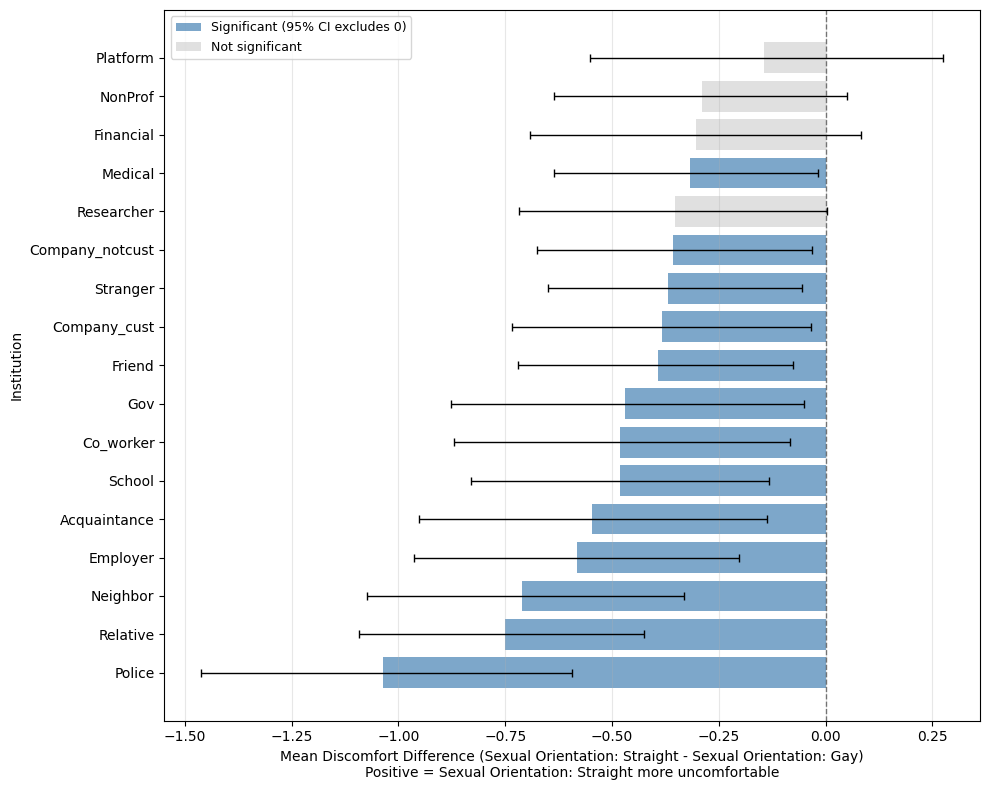

In [54]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Sexual_Orientation_straight', 'Dem_Sexual_Orientation_Gay',
    'Sexual Orientation: Straight', 'Sexual Orientation: Gay'
)

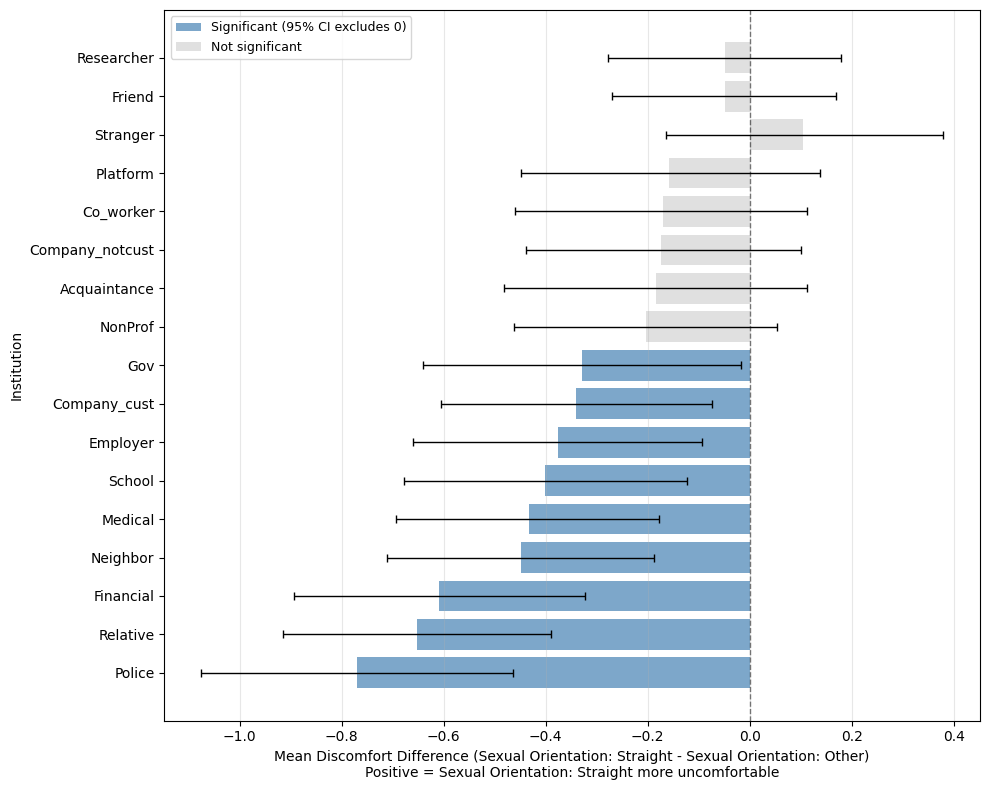

In [55]:
fig, results_df = plot_mean_difference(
    df_all, CONTEXTS,
    'Dem_Sexual_Orientation_straight', 'Dem_Sexual_Orientation_other',
    'Sexual Orientation: Straight', 'Sexual Orientation: Other'
)

#ACES Dose

In [56]:
def ace_trend_forest(df, contexts, ace_col="ACES_Compound", y_min=0, y_max=7,
                     save_path=None, dpi=300, show=True):
    rows = []
    for ctx in contexts:
        d = df[[ctx, ace_col]].dropna()
        # OrderedModel needs integer ordered responses
        y = d[ctx].astype(int).clip(y_min, y_max)
        X = d[[ace_col]]
        mod = OrderedModel(y, X, distr="logit")
        res = mod.fit(method="bfgs", disp=False)
        beta = res.params[ace_col]
        lo, hi = res.conf_int().loc[ace_col]
        rows.append({"context": ctx, "beta": beta, "lo": lo, "hi": hi, "n": len(d)})

    ef = pd.DataFrame(rows).sort_values("beta")
    y = np.arange(len(ef))

    plt.figure(figsize=(8, 0.45*len(ef)+1.5))
    # color significant effects
    sig = (ef["lo"]>0) | (ef["hi"]<0)
    colors = np.where(sig, "tab:orange", "0.6")

    plt.errorbar(ef["beta"], y, xerr=[ef["beta"]-ef["lo"], ef["hi"]-ef["beta"]],
                 fmt="o", capsize=3, elinewidth=1, ecolor="black", mfc="white")
    for i,c in enumerate(colors):
        plt.plot([ef["lo"].iloc[i], ef["hi"].iloc[i]], [y[i], y[i]], color=c, linewidth=4, alpha=0.6)

    plt.axvline(0, color="black", lw=1)
    plt.yticks(y, ef["context"])
    plt.xlabel("Ordinal logit coefficient for ACE count (per +1 ACE)\n(>0 = more uncomfortable with more ACEs)")
    plt.tight_layout()


#Rank Difference Approach

In [31]:
# Bootstrap rankings for a single group
def bootstrap_rankings_single_group(df, contexts, n_bootstrap=10000, random_state=42):
    np.random.seed(random_state)
    boot_ranks = {ctx: [] for ctx in contexts}

    for i in range(n_bootstrap):
        boot_sample = df.sample(n=len(df), replace=True)
        means = {ctx: boot_sample[ctx].mean() for ctx in contexts}
        sorted_contexts = sorted(means.items(), key=lambda x: x[1], reverse=True)

        for rank, (ctx, _) in enumerate(sorted_contexts, start=1):
            boot_ranks[ctx].append(rank)

    return boot_ranks

In [32]:
# Bootstrap comparison of institution rankings between two demographic groups

def bootstrap_demographic_comparison(df, contexts, demo_col1, demo_col2, group1_name, group2_name,
                                     n_bootstrap=10000, random_state=42):
    np.random.seed(random_state)

    df_g1 = df[df[demo_col1] == 1].copy()
    df_g2 = df[df[demo_col2] == 1].copy()

    print(f"{group1_name}: n={len(df_g1)}")
    print(f"{group2_name}: n={len(df_g2)}")

    rank_diffs = {ctx: [] for ctx in contexts}

    for i in range(n_bootstrap):
        boot_g1 = df_g1.sample(n=len(df_g1), replace=True)
        boot_g2 = df_g2.sample(n=len(df_g2), replace=True)

        means_g1 = {ctx: boot_g1[ctx].mean() for ctx in contexts}
        means_g2 = {ctx: boot_g2[ctx].mean() for ctx in contexts}

        sorted_g1 = sorted(means_g1.items(), key=lambda x: x[1], reverse=True)
        sorted_g2 = sorted(means_g2.items(), key=lambda x: x[1], reverse=True)

        ranks_g1 = {ctx: rank for rank, (ctx, _) in enumerate(sorted_g1, start=1)}
        ranks_g2 = {ctx: rank for rank, (ctx, _) in enumerate(sorted_g2, start=1)}
        for ctx in contexts:
            rank_diffs[ctx].append(ranks_g2[ctx] - ranks_g1[ctx])

    results = []
    for ctx in contexts:
        diffs = rank_diffs[ctx]
        results.append({
            'institution': ctx.replace('TP_', ''),
            'rank_diff_mean': np.mean(diffs),
            'rank_diff_lo': np.percentile(diffs, 2.5),
            'rank_diff_hi': np.percentile(diffs, 97.5),
            'significant': not (np.percentile(diffs, 2.5) <= 0 <= np.percentile(diffs, 97.5))
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('rank_diff_mean', key=abs, ascending=False)

    return results_df, df_g1, df_g2

In [33]:
# Plot ranking with CIs for a single group

def plot_single_group_ranking(df_group, contexts, group_name, save_path=None):
    boot_ranks = bootstrap_rankings_single_group(df_group, contexts, n_bootstrap=10000)

    rank_table = []
    for ctx in contexts:
        ranks = boot_ranks[ctx]
        rank_table.append({
            'institution': ctx.replace('TP_', ''),
            'rank_mean': np.mean(ranks),
            'rank_lo': np.percentile(ranks, 2.5),
            'rank_hi': np.percentile(ranks, 97.5),
            'actual_mean': df_group[ctx].mean()
        })

    rank_table = pd.DataFrame(rank_table)
    rank_table = rank_table.sort_values('rank_mean')
    rank_table.index = rank_table['institution']

    # Create plot
    fig, ax = plt.subplots(figsize=(8, 6))
    y = np.arange(len(rank_table))

    ax.hlines(y, rank_table["rank_lo"], rank_table["rank_hi"], color='steelblue', alpha=0.6)
    ax.plot(rank_table["rank_mean"], y, "o", color='steelblue', markersize=8)

    ax.set_yticks(y)
    ax.set_yticklabels(rank_table.index)
    ax.invert_xaxis()
    ax.set_xlabel("Bootstrap rank (95% CI) — lower = more uncomfortable")
    ax.set_title(f"Rank robustness — {group_name}")
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return fig, rank_table

In [34]:
# Create bar plot showing rank differences between groups

def plot_rank_diff_bar(results_df, group1_name, group2_name, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 8))
    y_pos = np.arange(len(results_df))

    colors = ['steelblue' if sig else 'lightgray' for sig in results_df['significant']]
    ax.barh(y_pos, results_df['rank_diff_mean'], color=colors, alpha=0.7)

    xerr = np.abs(results_df[['rank_diff_lo', 'rank_diff_hi']].values.T - results_df['rank_diff_mean'].values)
    ax.errorbar(results_df['rank_diff_mean'], y_pos, xerr=xerr,
                fmt='none', color='black', capsize=3, linewidth=1)

    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(results_df['institution'])
    ax.set_xlabel(f'Rank Difference ({group1_name} - {group2_name})\nPositive = {group1_name} more uncomfortable')
    ax.set_ylabel('Institution')
    ax.set_title(f'Privacy Ranking Differences: {group1_name} vs {group2_name}',
                 fontweight='bold', fontsize=12)

    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Significant (95% CI excludes 0)'),
        Patch(facecolor='lightgray', alpha=0.7, label='Not significant')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return fig, ax

In [35]:
def analyze_demographic_pair(df, contexts, demo_col1, demo_col2, group1_name, group2_name,
                             output_dir=None, n_bootstrap=10000):
    # Get data for each group
    df_g1 = df[df[demo_col1] == 1]
    df_g2 = df[df[demo_col2] == 1]

    # Individual group rankings
    print(f"\n1. {group1_name} Rankings")
    print("-"*70)
    save_path1 = f"{output_dir}/{group1_name.lower()}_rank_ci.pdf" if output_dir else None
    fig1, rank_table1 = plot_single_group_ranking(df_g1, contexts, group1_name, save_path1)
    print(rank_table1[['rank_mean', 'rank_lo', 'rank_hi', 'actual_mean']])

    print(f"\n2. {group2_name} Rankings")
    print("-"*70)
    save_path2 = f"{output_dir}/{group2_name.lower()}_rank_ci.pdf" if output_dir else None
    fig2, rank_table2 = plot_single_group_ranking(df_g2, contexts, group2_name, save_path2)
    print(rank_table2[['rank_mean', 'rank_lo', 'rank_hi', 'actual_mean']])

    # Comparison
    print(f"\n3. Comparing {group1_name} vs {group2_name}")
    print("-"*70)
    results_df, _, _ = bootstrap_demographic_comparison(
        df, contexts, demo_col1, demo_col2, group1_name, group2_name, n_bootstrap=n_bootstrap
    )
    print("\nRank Differences:")
    print(results_df[['institution', 'rank_diff_mean', 'rank_diff_lo', 'rank_diff_hi', 'significant']])

    # Rank difference bar plot
    save_path3 = f"{output_dir}/{group1_name.lower()}_{group2_name.lower()}_rankdiff.pdf" if output_dir else None
    fig3, ax3 = plot_rank_diff_bar(results_df, group1_name, group2_name, save_path3)

    return {
        'results_df': results_df,
        'rank_table_g1': rank_table1,
        'rank_table_g2': rank_table2
    }

##gender

In [36]:
output_dir = '/filepath'



1. Women Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0000      1.0      1.0     6.029900
Company_notcust     2.0000      2.0      2.0     5.481728
Platform            3.2427      3.0      4.0     4.774834
Company_cust        3.7573      3.0      4.0     4.736318
Acquaintance        5.2434      5.0      7.0     4.478477
Police              6.3699      5.0      8.0     4.399334
Neighbor            6.6203      5.0      8.0     4.390728
Gov                 8.2404      7.0      9.0     4.298013
Co_worker           8.5275      7.0      9.0     4.274834
NonProf             9.9985     10.0     10.0     4.076159
Financial          11.4064     11.0     12.0     3.742525
School             11.6066     11.0     12.0     3.728477
Employer           12.9870     13.0     13.0     3.604305
Researcher         14.0000     14.0     

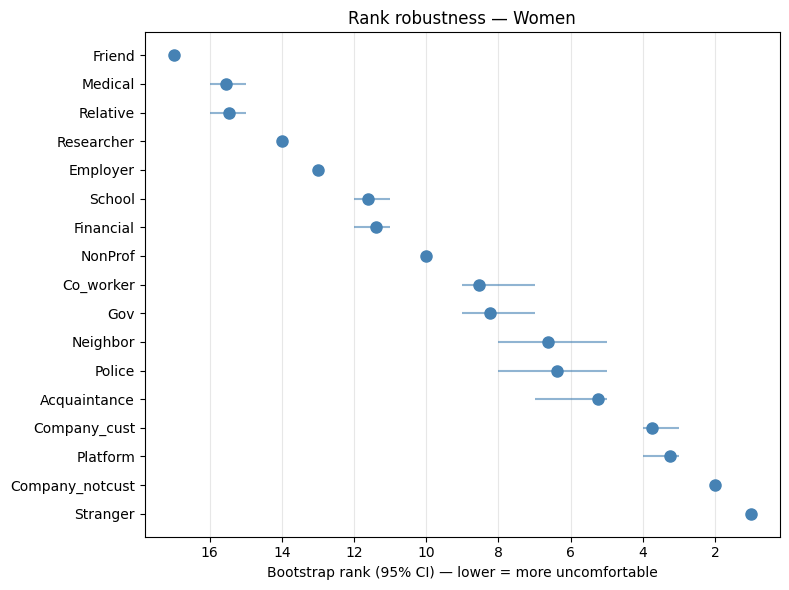

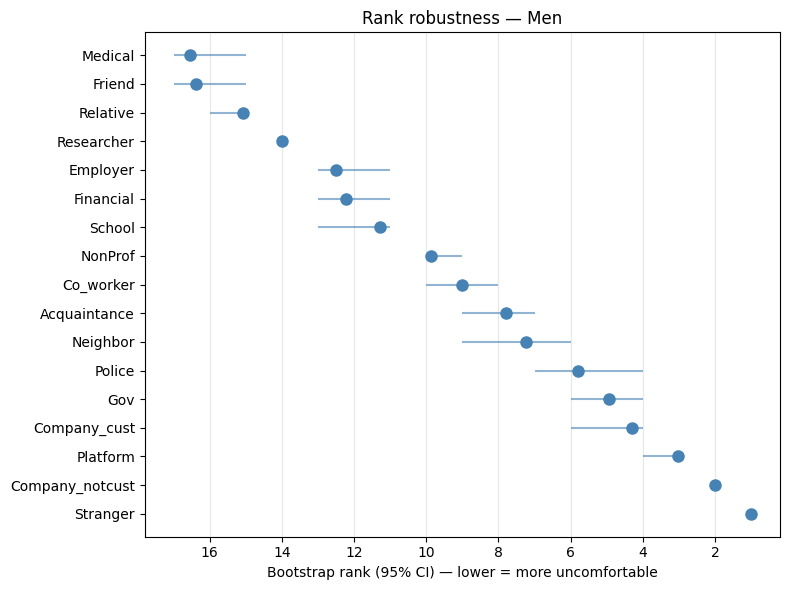

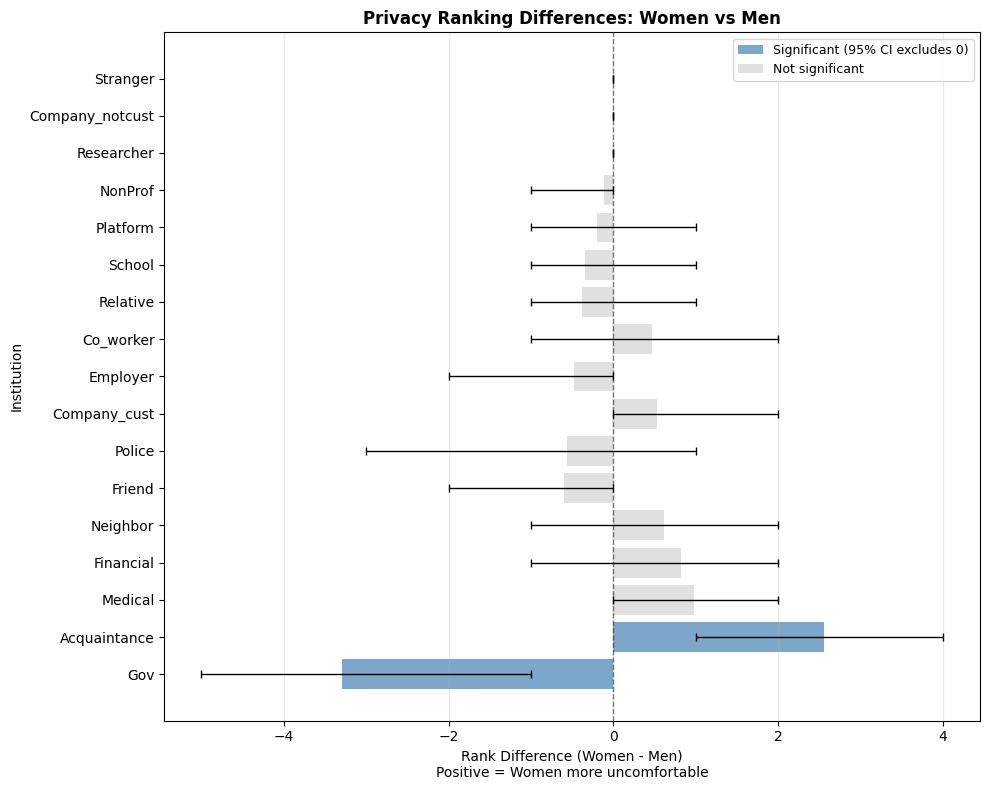

In [37]:
# men vs women
menwomen_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Gender_Woman', 'Dem_Gender_Man',
    'Women', 'Men',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. Non-binary Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0027      1.0      1.0     5.928571
Company_notcust     2.0566      2.0      3.0     5.580357
Police              2.9583      2.0      3.0     5.294643
Company_cust        4.7505      4.0      7.0     4.919643
Gov                 5.3235      4.0      7.0     4.866071
Neighbor            5.8738      4.0      7.0     4.803571
Platform            6.0773      4.0      7.0     4.783784
Acquaintance        8.1098      7.0      9.0     4.446429
Financial           9.6170      8.0     13.0     4.196429
School             11.0166      9.0     13.0     4.080357
Co_worker          11.0549      9.0     13.0     4.071429
NonProf            11.2335      9.0     13.0     4.062500
Employer           11.9255      9.0     13.0     4.000000
Relative           14.3954     14.0

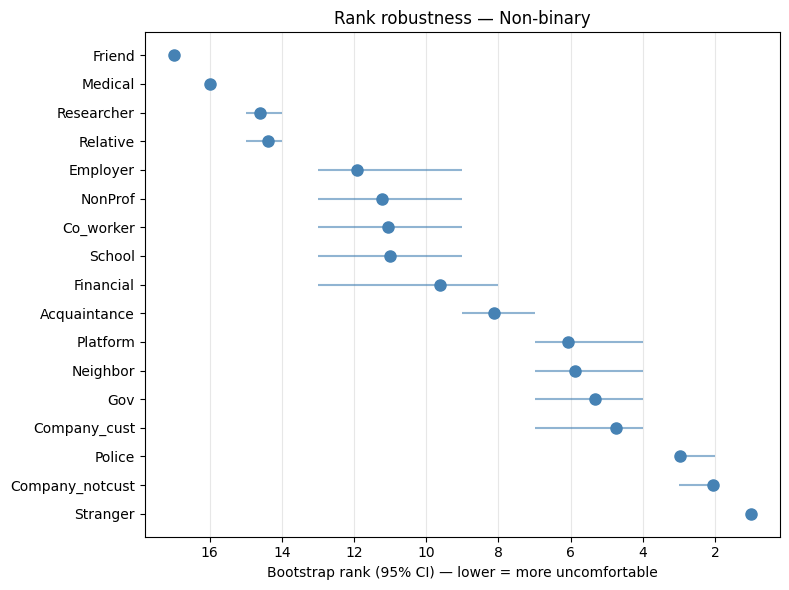

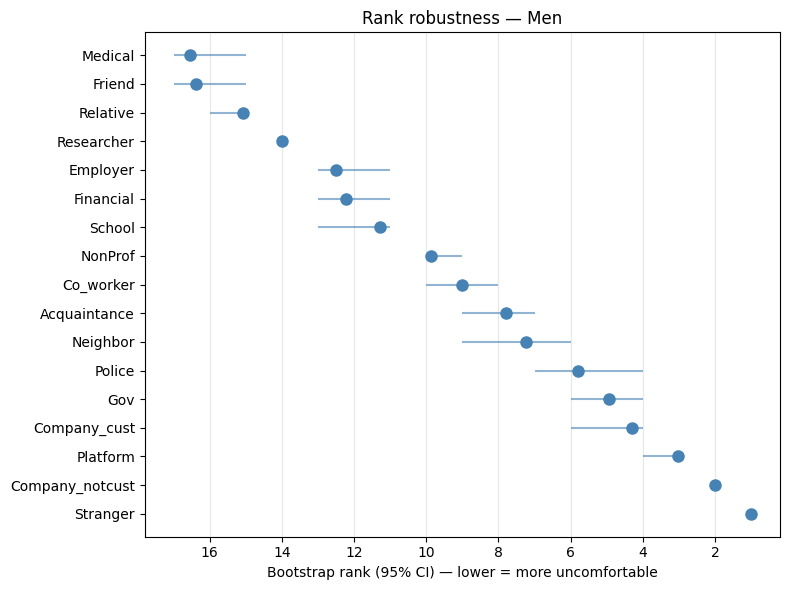

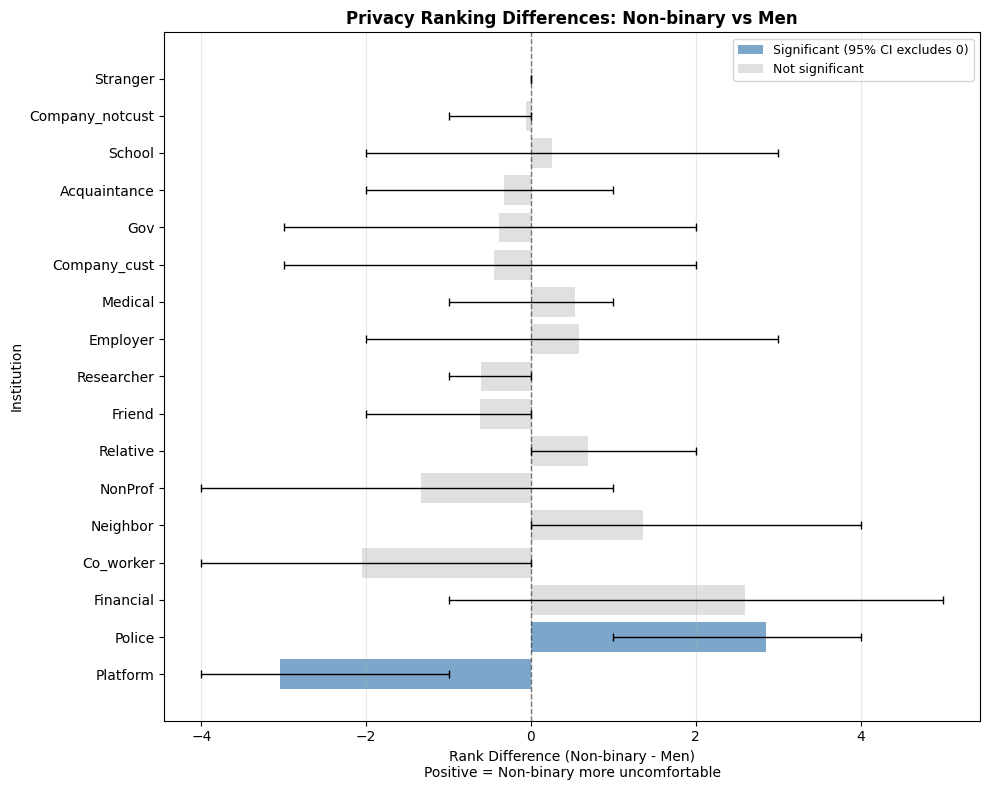

In [38]:
othermen_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Gender_Other', 'Dem_Gender_Man',
    'Non-binary', 'Men',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. Non-binary Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0027      1.0      1.0     5.928571
Company_notcust     2.0566      2.0      3.0     5.580357
Police              2.9583      2.0      3.0     5.294643
Company_cust        4.7505      4.0      7.0     4.919643
Gov                 5.3235      4.0      7.0     4.866071
Neighbor            5.8738      4.0      7.0     4.803571
Platform            6.0773      4.0      7.0     4.783784
Acquaintance        8.1098      7.0      9.0     4.446429
Financial           9.6170      8.0     13.0     4.196429
School             11.0166      9.0     13.0     4.080357
Co_worker          11.0549      9.0     13.0     4.071429
NonProf            11.2335      9.0     13.0     4.062500
Employer           11.9255      9.0     13.0     4.000000
Relative           14.3954     14.0

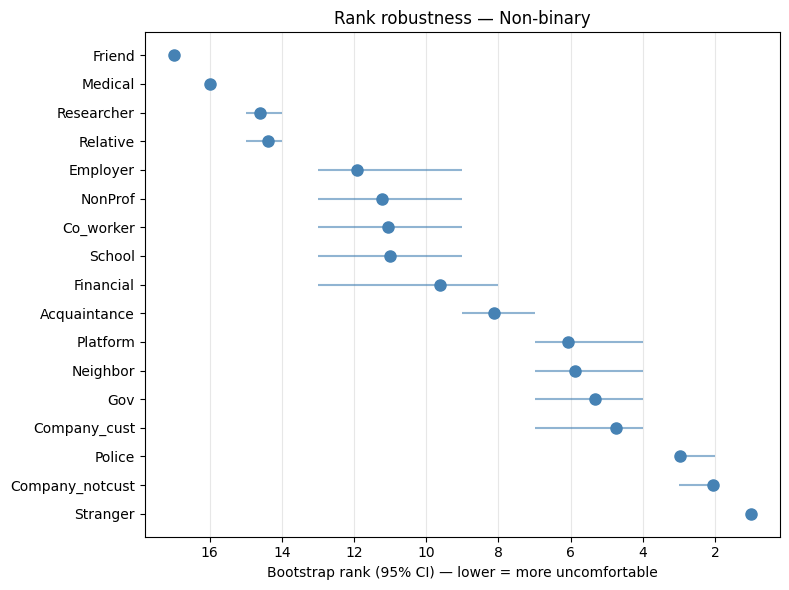

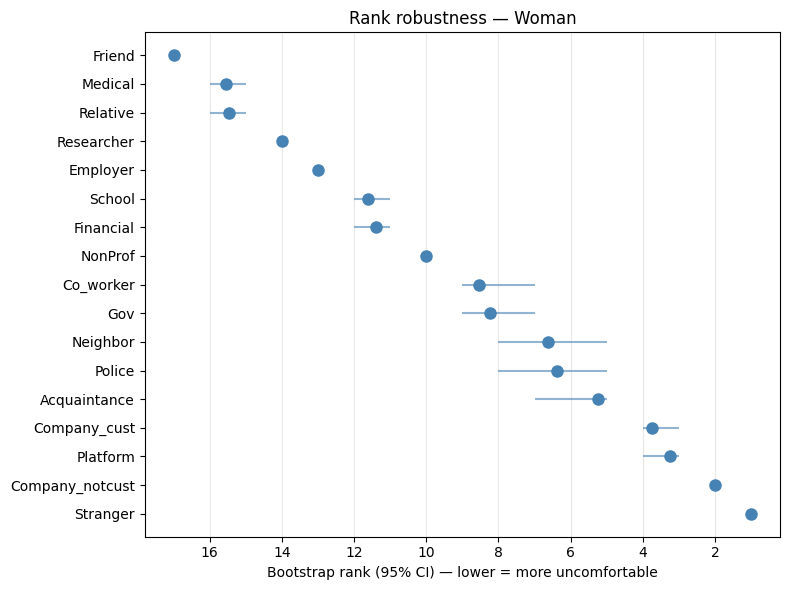

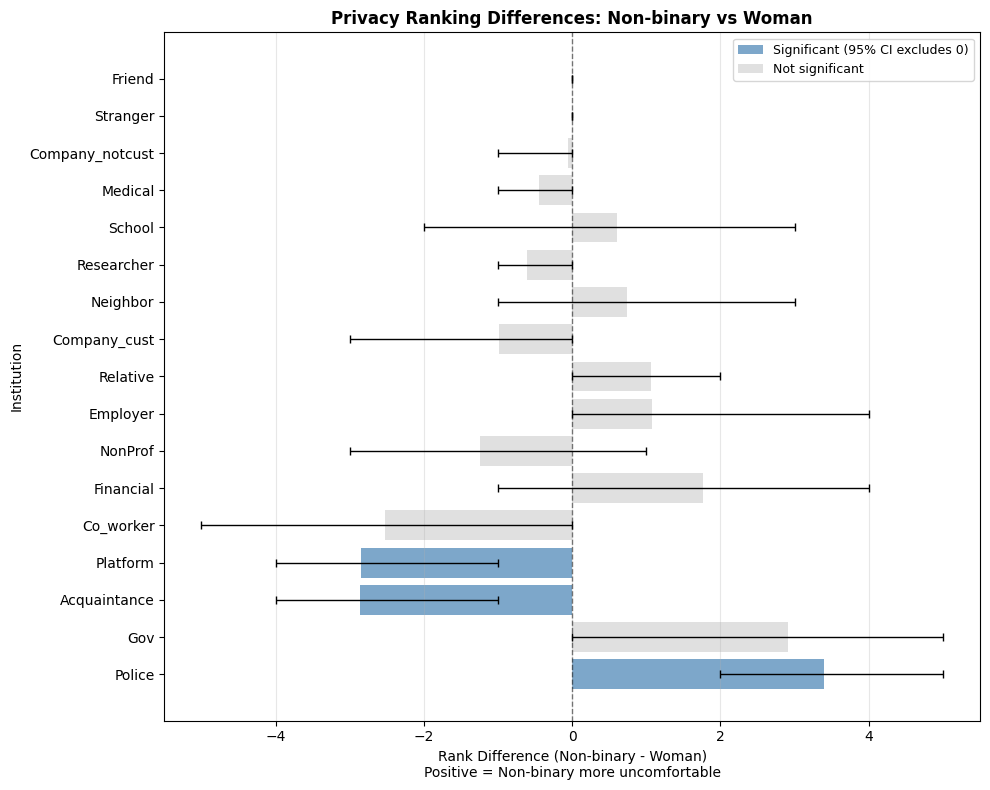

In [39]:
womemenother_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Gender_Other', 'Dem_Gender_Woman',
    'Non-binary', 'Woman',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. Therapy Yes Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0000      1.0      1.0     5.970313
Company_notcust     2.0000      2.0      2.0     5.503125
Platform            3.0878      3.0      4.0     4.812207
Company_cust        3.9177      3.0      4.0     4.737500
Police              5.0478      5.0      6.0     4.538462
Gov                 6.7566      6.0      8.0     4.400000
Acquaintance        6.7719      5.0      8.0     4.392801
Neighbor            7.4263      6.0      8.0     4.360938
Co_worker           8.9967      9.0      9.0     4.200000
NonProf             9.9952     10.0     10.0     4.053125
Financial          11.1892     11.0     12.0     3.760563
School             11.8460     11.0     13.0     3.710938
Employer           12.9648     12.0     13.0     3.616588
Researcher         14.0000     14.

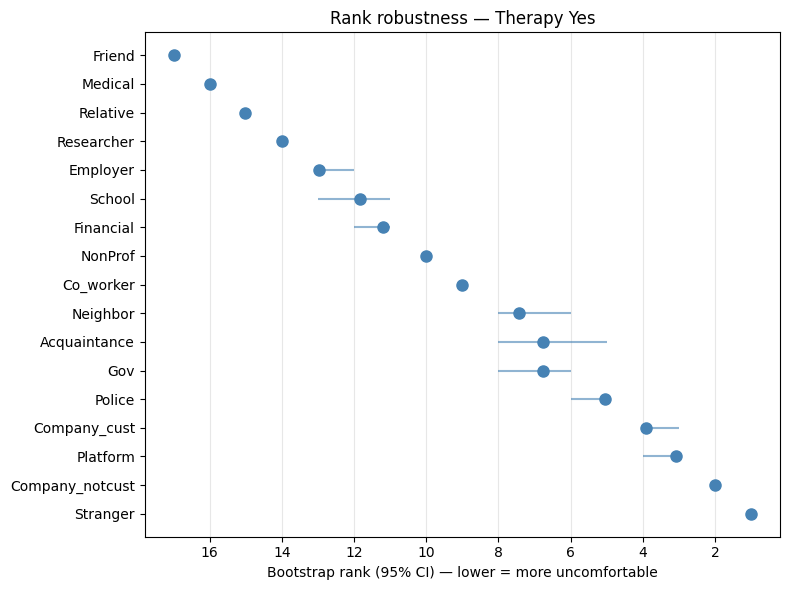

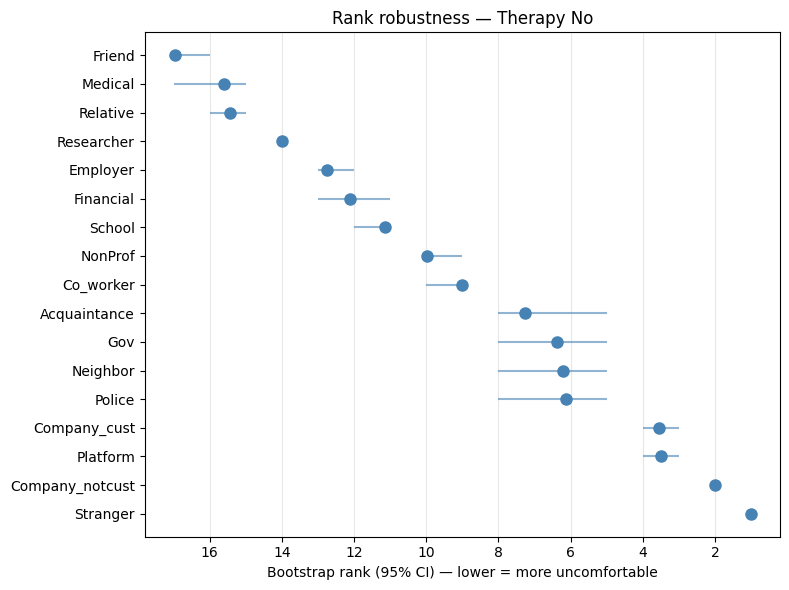

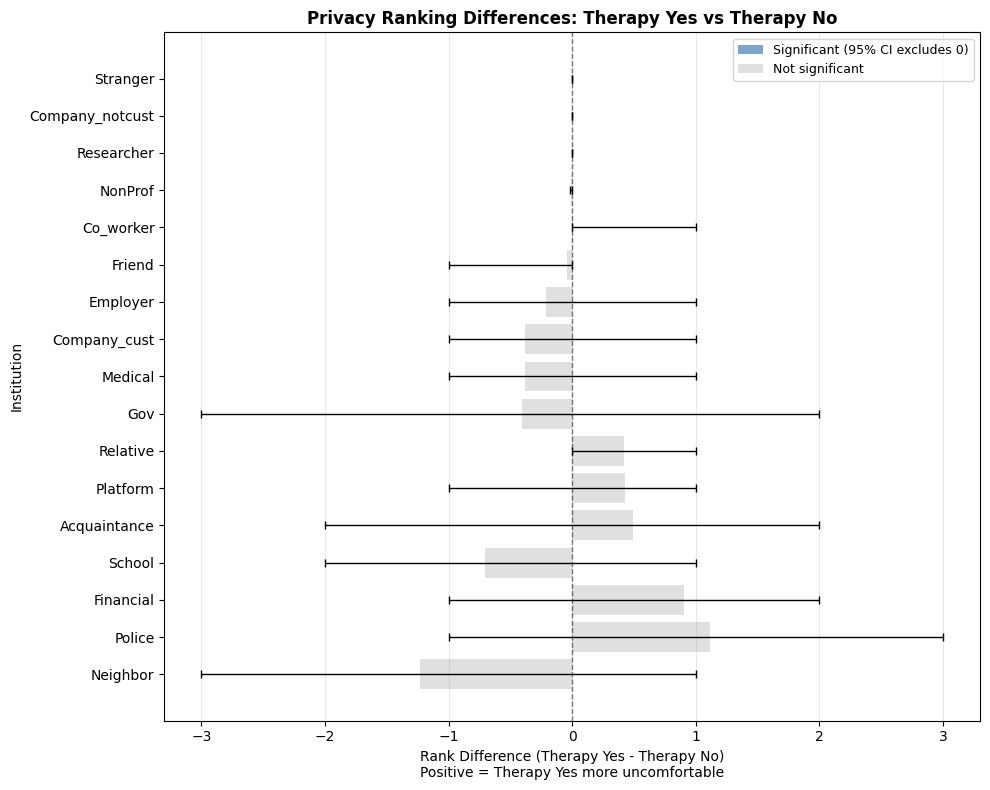

In [40]:
therapy_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Therapy_Yes', 'Dem_Therapy_No',
    'Therapy Yes', 'Therapy No',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. First Generation Yes Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0000      1.0      1.0     5.888889
Company_notcust     2.0033      2.0      2.0     5.148148
Neighbor            4.3726      3.0      7.0     4.604938
Police              4.7595      3.0      8.0     4.575000
Company_cust        5.0577      3.0      8.0     4.555556
Platform            5.6247      3.0      8.0     4.506173
Gov                 6.2612      3.0      9.0     4.456790
Acquaintance        7.0721      4.0      9.0     4.382716
Financial           9.9698      8.0     13.0     4.049383
Co_worker          10.1161      8.0     13.0     4.049383
NonProf            10.8369      9.0     13.0     3.975309
Employer           11.6156      9.0     13.0     3.888889
School             12.3107     10.0     13.0     3.827160
Researcher         14.247

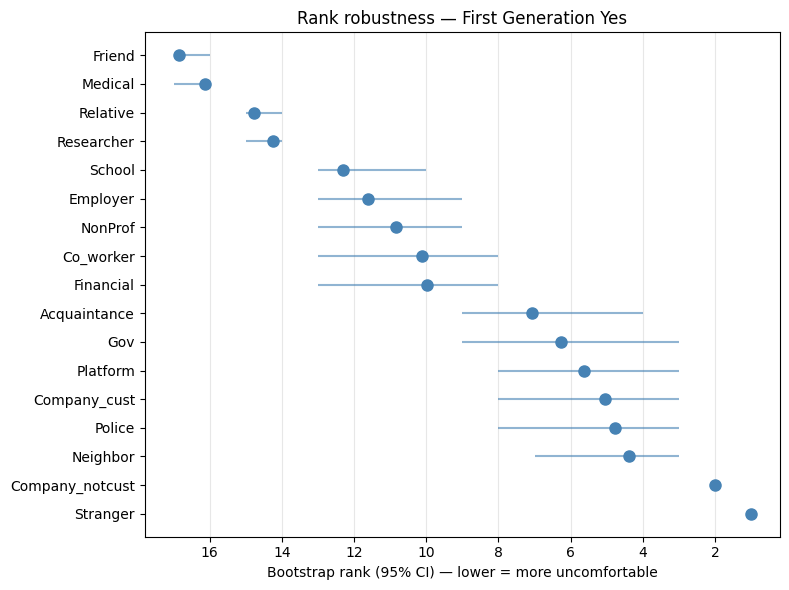

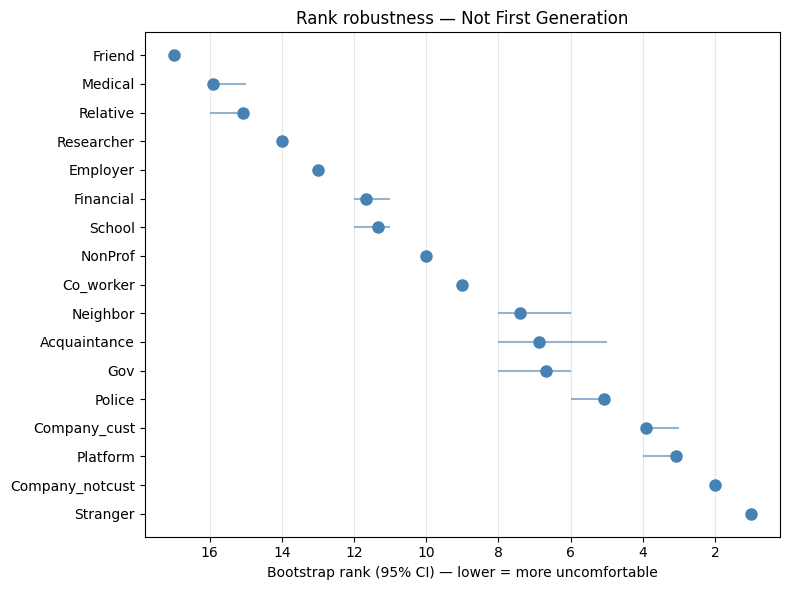

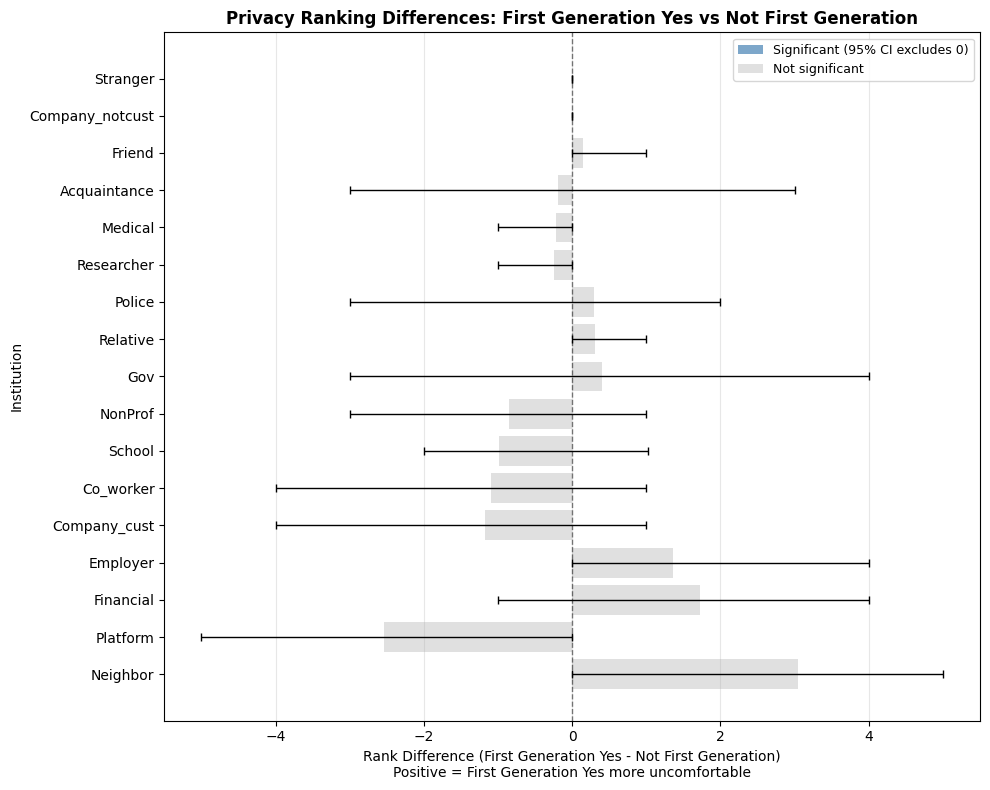

In [41]:
firtgen_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_FirtsGen_Yes', 'Dem_FirtsGen_No',
    'First Generation Yes', 'Not First Generation',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. White Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0000      1.0      1.0     5.948509
Company_notcust     2.0000      2.0      2.0     5.471545
Platform            3.3162      3.0      4.0     4.699594
Company_cust        3.6838      3.0      4.0     4.675237
Police              5.5467      5.0      7.0     4.402985
Acquaintance        5.9728      5.0      8.0     4.378890
Neighbor            7.0820      5.0      8.0     4.331081
Gov                 7.4238      6.0      8.0     4.309459
Co_worker           8.9748      9.0      9.0     4.162162
NonProf             9.9999     10.0     10.0     3.970270
School             11.2763     11.0     12.0     3.677027
Financial          11.7289     11.0     12.0     3.646341
Employer           12.9948     13.0     13.0     3.518970
Researcher         14.0000     14.0     

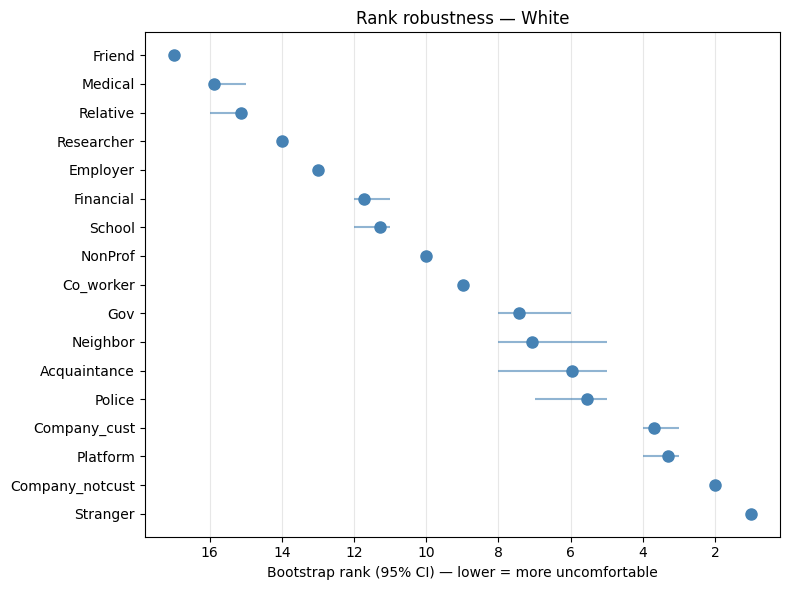

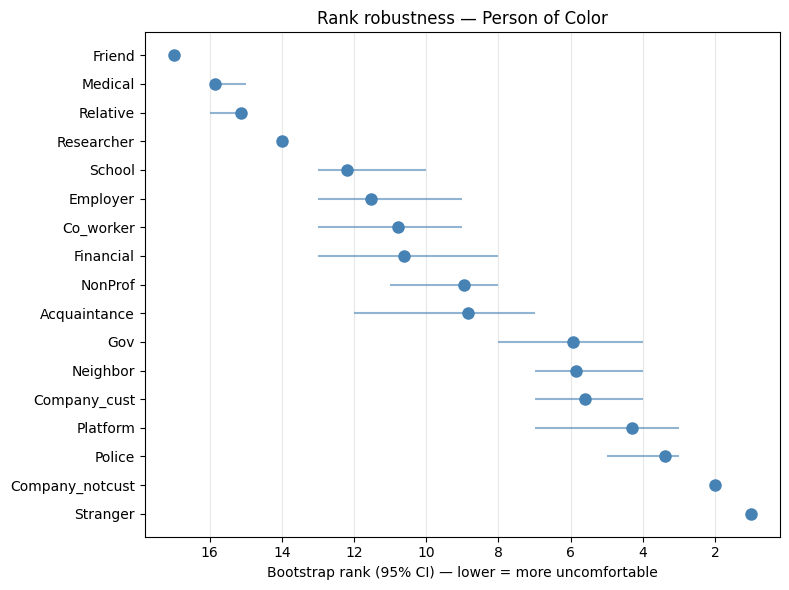

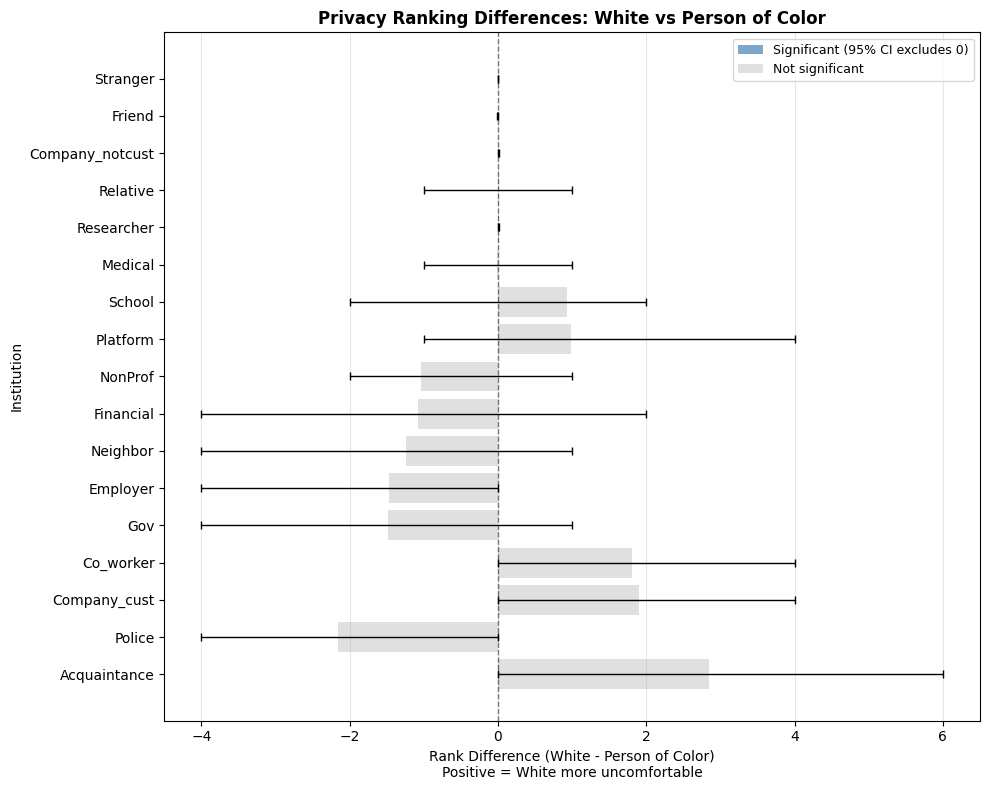

In [42]:
whitepoc_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Race_White', 'Dem_Race_POC',
    'White', 'Person of Color',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. Multi-racial Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0002      1.0      1.0     5.841121
Company_notcust     2.0011      2.0      2.0     5.317757
Platform            3.3818      3.0      5.0     4.887850
Police              4.6820      3.0      6.0     4.719626
Company_cust        4.9666      4.0      6.0     4.710280
Gov                 4.9763      3.0      6.0     4.691589
Acquaintance        7.6050      7.0     10.0     4.177570
Neighbor            7.9093      7.0     10.0     4.149533
Co_worker           9.0598      7.0     12.0     4.056075
NonProf            10.4666      8.0     13.0     3.925234
Financial          11.1392      8.0     13.0     3.850467
Employer           11.8991      9.0     13.0     3.785047
School             11.9131     10.0     13.0     3.794393
Researcher         14.0003     14

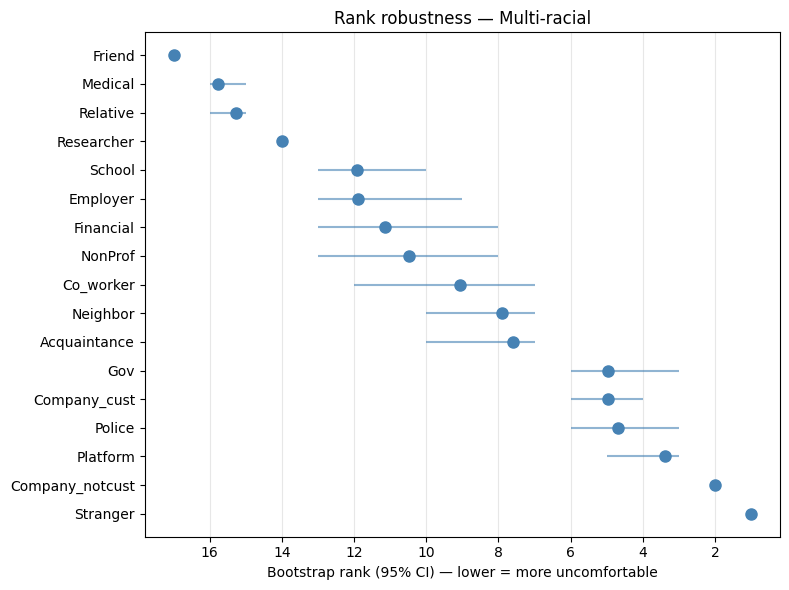

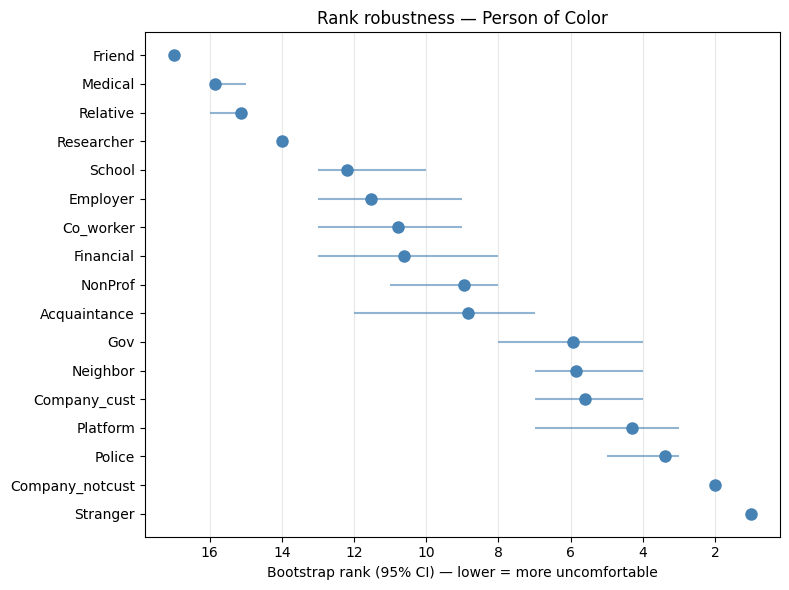

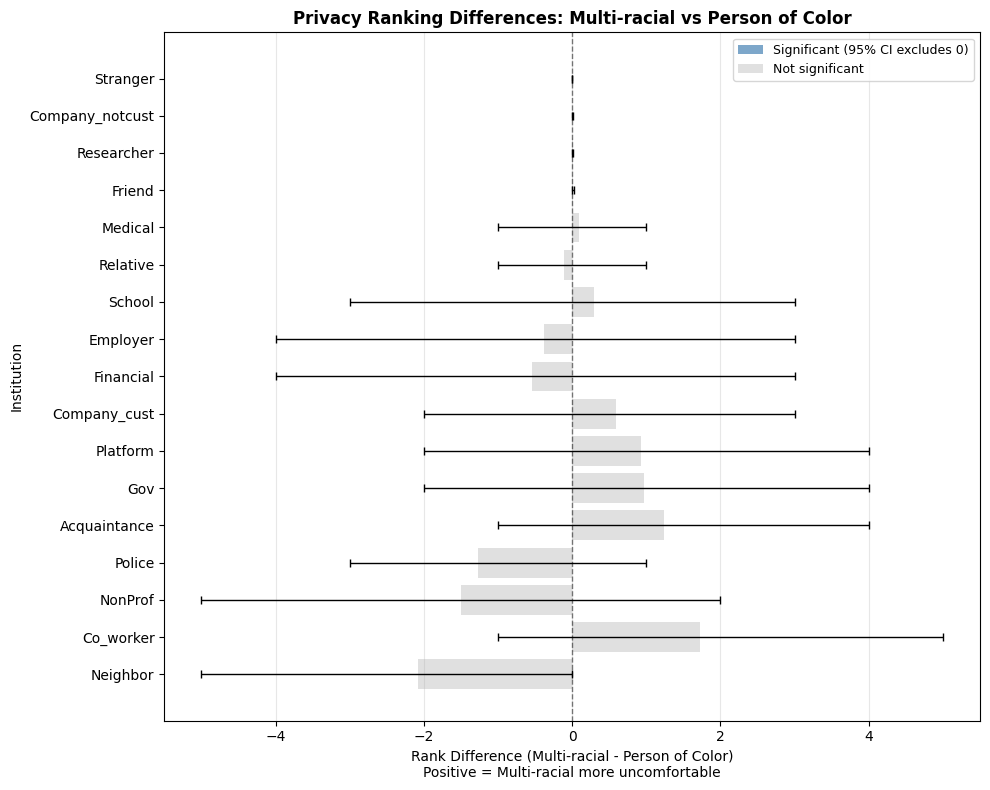

In [43]:
mixedpoc_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Race_Mixed', 'Dem_Race_POC',
    'Multi-racial', 'Person of Color',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. Multi-racial Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0002      1.0      1.0     5.841121
Company_notcust     2.0011      2.0      2.0     5.317757
Platform            3.3818      3.0      5.0     4.887850
Police              4.6820      3.0      6.0     4.719626
Company_cust        4.9666      4.0      6.0     4.710280
Gov                 4.9763      3.0      6.0     4.691589
Acquaintance        7.6050      7.0     10.0     4.177570
Neighbor            7.9093      7.0     10.0     4.149533
Co_worker           9.0598      7.0     12.0     4.056075
NonProf            10.4666      8.0     13.0     3.925234
Financial          11.1392      8.0     13.0     3.850467
Employer           11.8991      9.0     13.0     3.785047
School             11.9131     10.0     13.0     3.794393
Researcher         14.0003     14

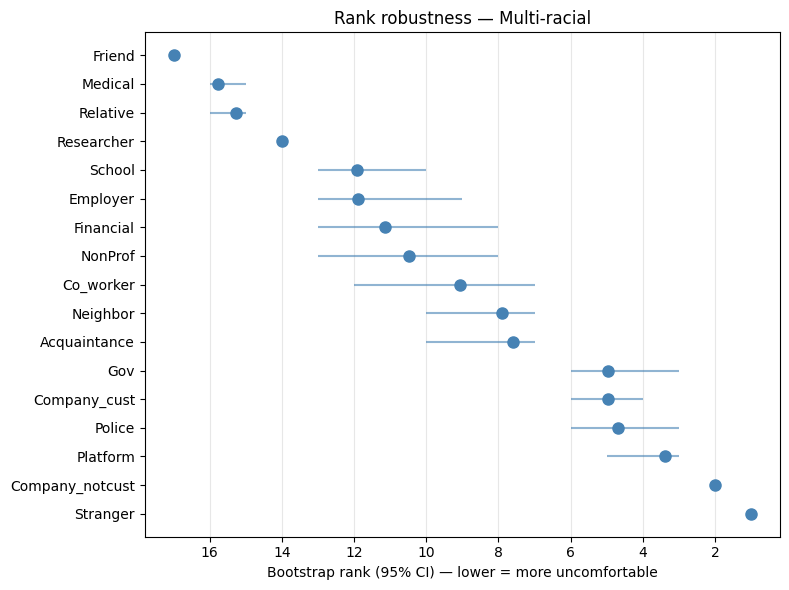

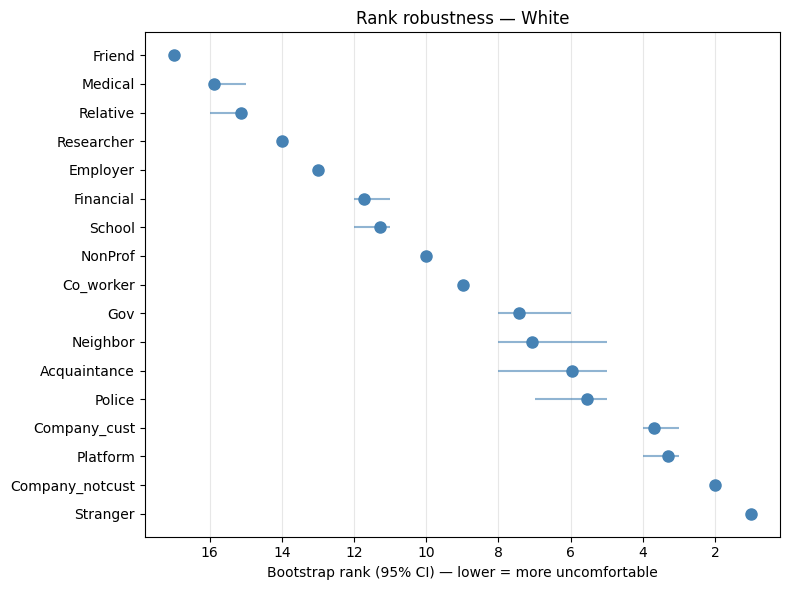

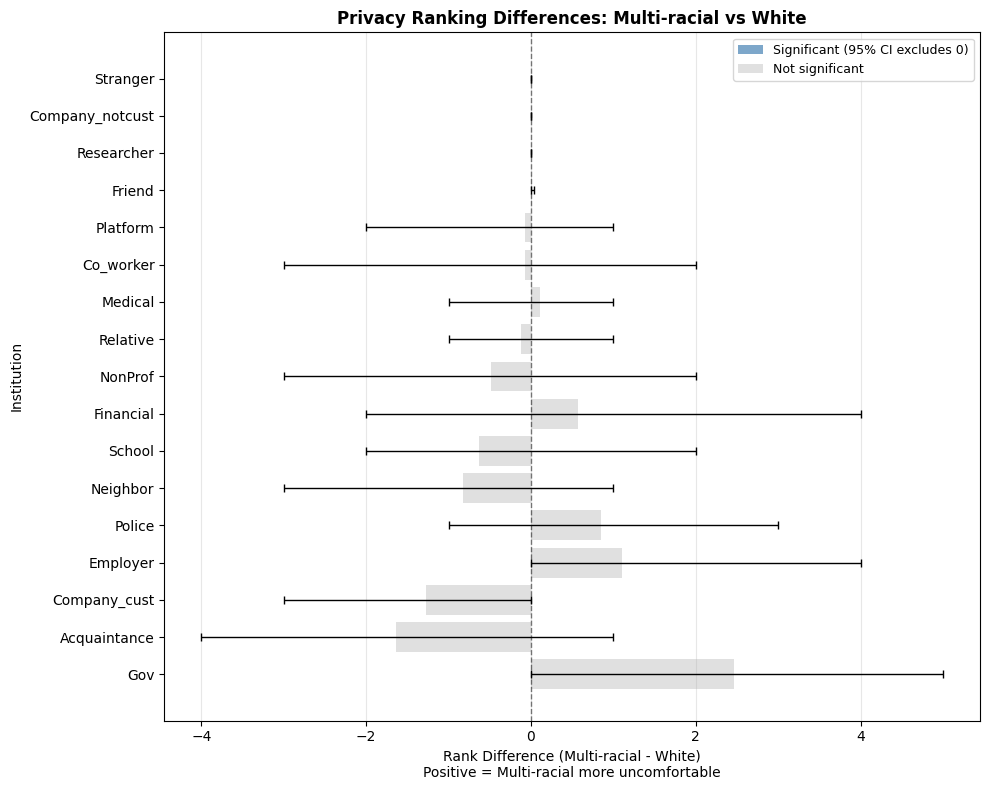

In [44]:
mixedwhite_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Race_Mixed', 'Dem_Race_White',
    'Multi-racial', 'White',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. Sexual Orientation: Straight Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0000      1.0      1.0     5.899772
Company_notcust     2.0000      2.0      2.0     5.359091
Platform            3.0055      3.0      3.0     4.684807
Company_cust        3.9946      4.0      4.0     4.527273
Acquaintance        5.5510      5.0      7.0     4.219955
Gov                 5.5906      5.0      7.0     4.224490
Neighbor            7.2459      6.0      9.0     4.097506
Co_worker           8.2053      7.0      9.0     4.043084
Police              8.4959      7.0     10.0     4.018265
NonProf             9.9112      9.0     10.0     3.888889
School             11.1833     11.0     12.0     3.519274
Financial          11.9274     11.0     13.0     3.454545
Employer           12.8893     12.0     13.0     3.369021
Researcher       

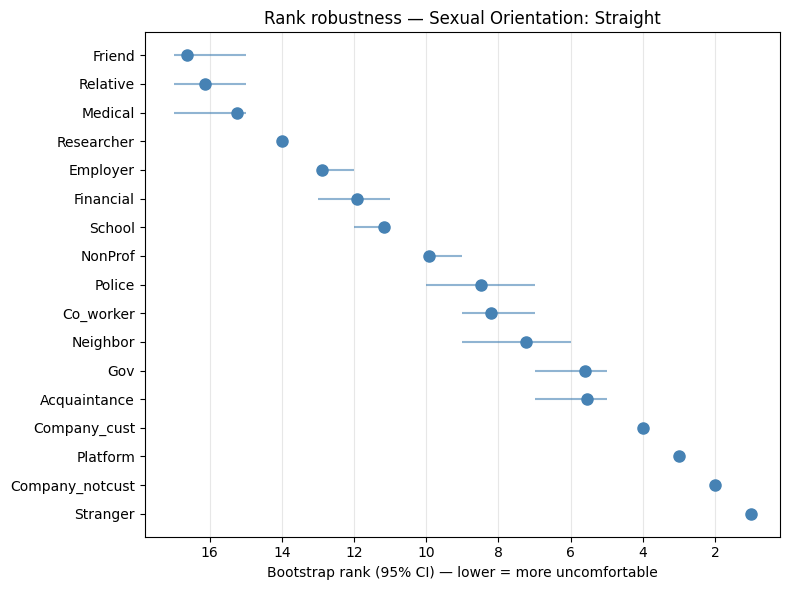

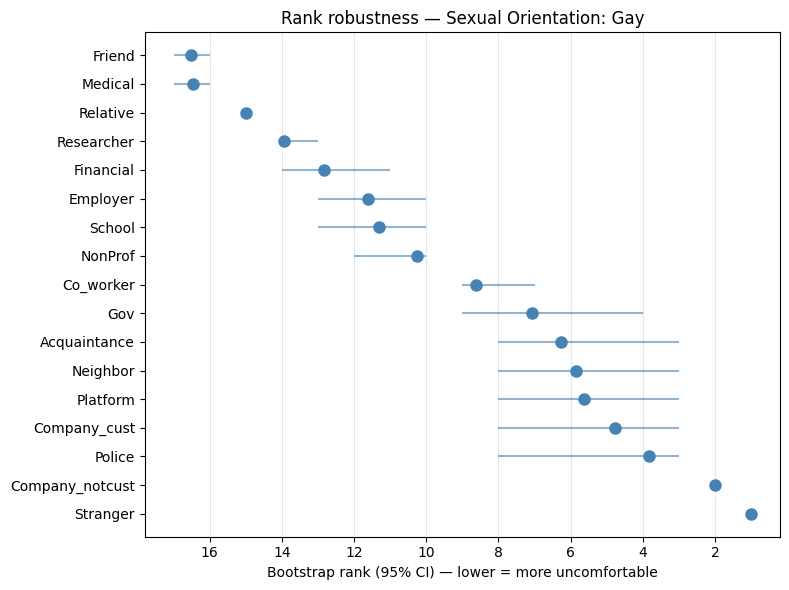

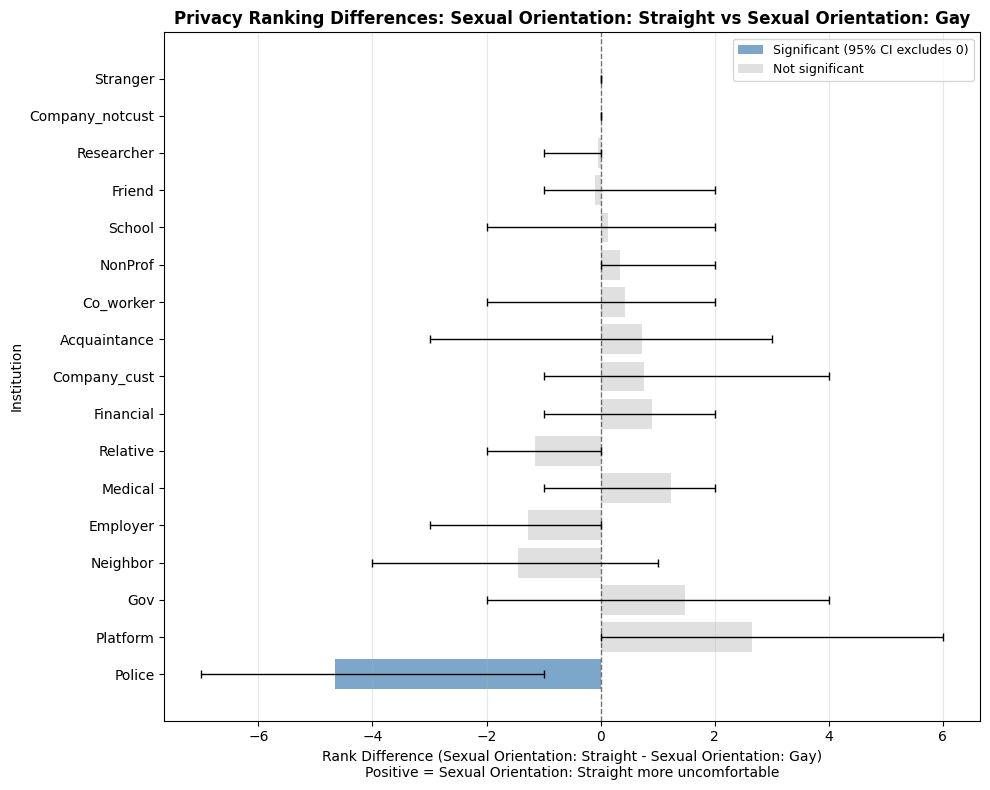

In [45]:
straightgay_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Sexual_Orientation_straight', 'Dem_Sexual_Orientation_Gay',
    'Sexual Orientation: Straight', 'Sexual Orientation: Gay',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. Sexual Orientation: Straight Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0000      1.0      1.0     5.899772
Company_notcust     2.0000      2.0      2.0     5.359091
Platform            3.0055      3.0      3.0     4.684807
Company_cust        3.9946      4.0      4.0     4.527273
Acquaintance        5.5510      5.0      7.0     4.219955
Gov                 5.5906      5.0      7.0     4.224490
Neighbor            7.2459      6.0      9.0     4.097506
Co_worker           8.2053      7.0      9.0     4.043084
Police              8.4959      7.0     10.0     4.018265
NonProf             9.9112      9.0     10.0     3.888889
School             11.1833     11.0     12.0     3.519274
Financial          11.9274     11.0     13.0     3.454545
Employer           12.8893     12.0     13.0     3.369021
Researcher       

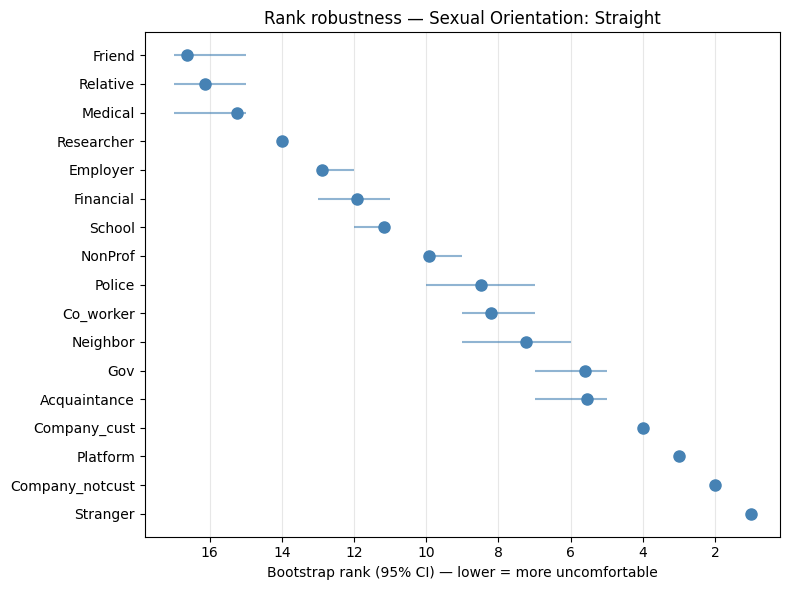

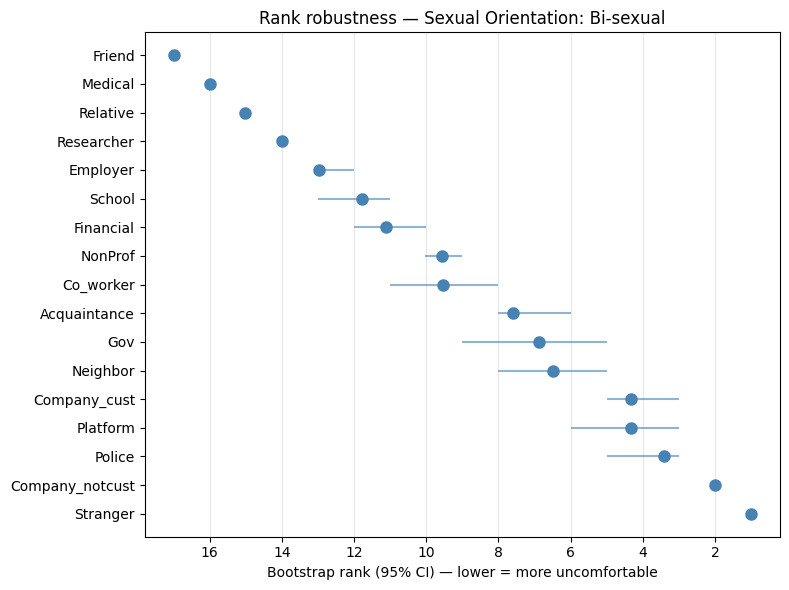

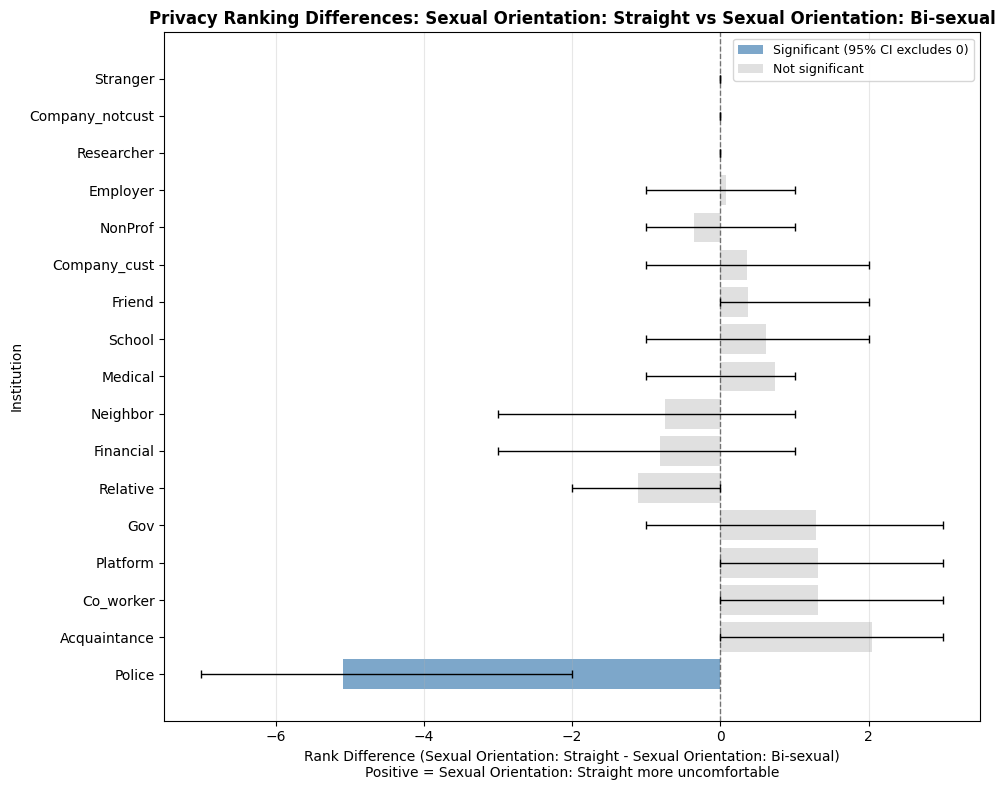

In [46]:
straightbi_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Sexual_Orientation_straight', 'Dem_Sexual_Orientation_Bisexual',
    'Sexual Orientation: Straight', 'Sexual Orientation: Bi-sexual',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. Sexual Orientation: Straight Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0000      1.0      1.0     5.899772
Company_notcust     2.0000      2.0      2.0     5.359091
Platform            3.0055      3.0      3.0     4.684807
Company_cust        3.9946      4.0      4.0     4.527273
Acquaintance        5.5510      5.0      7.0     4.219955
Gov                 5.5906      5.0      7.0     4.224490
Neighbor            7.2459      6.0      9.0     4.097506
Co_worker           8.2053      7.0      9.0     4.043084
Police              8.4959      7.0     10.0     4.018265
NonProf             9.9112      9.0     10.0     3.888889
School             11.1833     11.0     12.0     3.519274
Financial          11.9274     11.0     13.0     3.454545
Employer           12.8893     12.0     13.0     3.369021
Researcher       

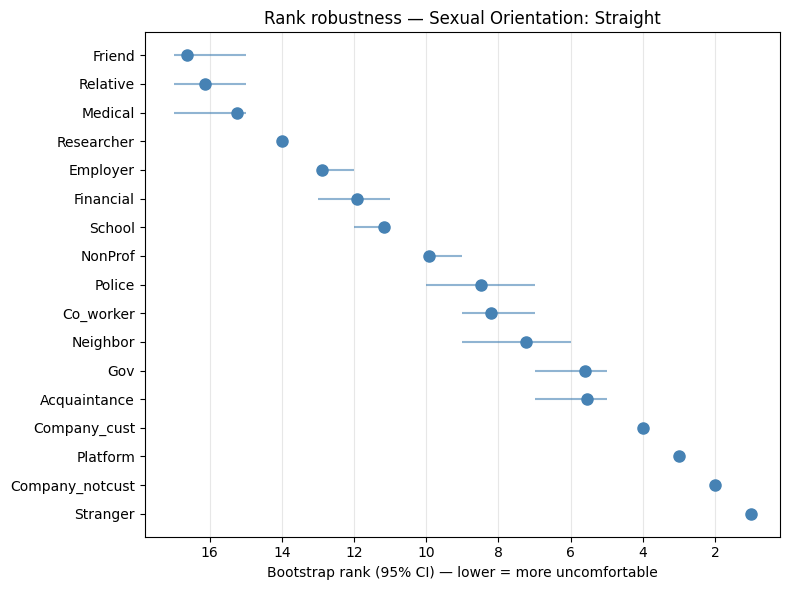

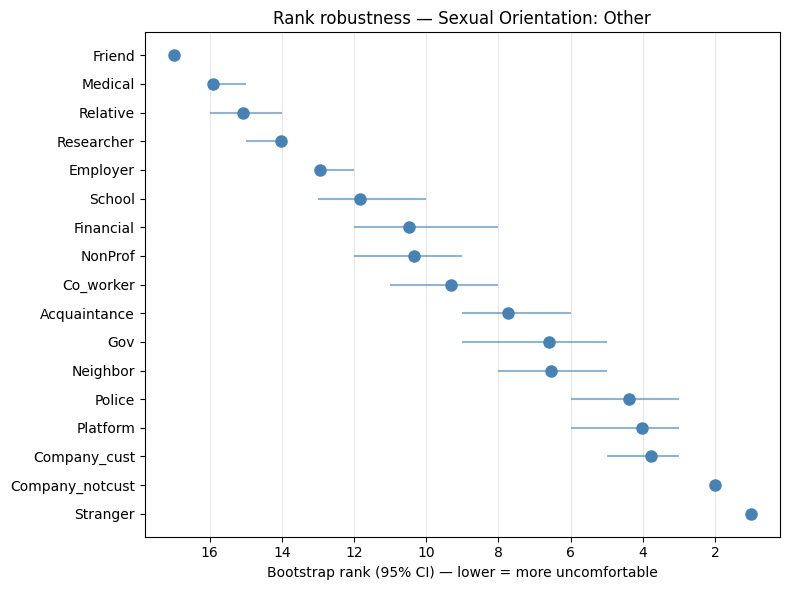

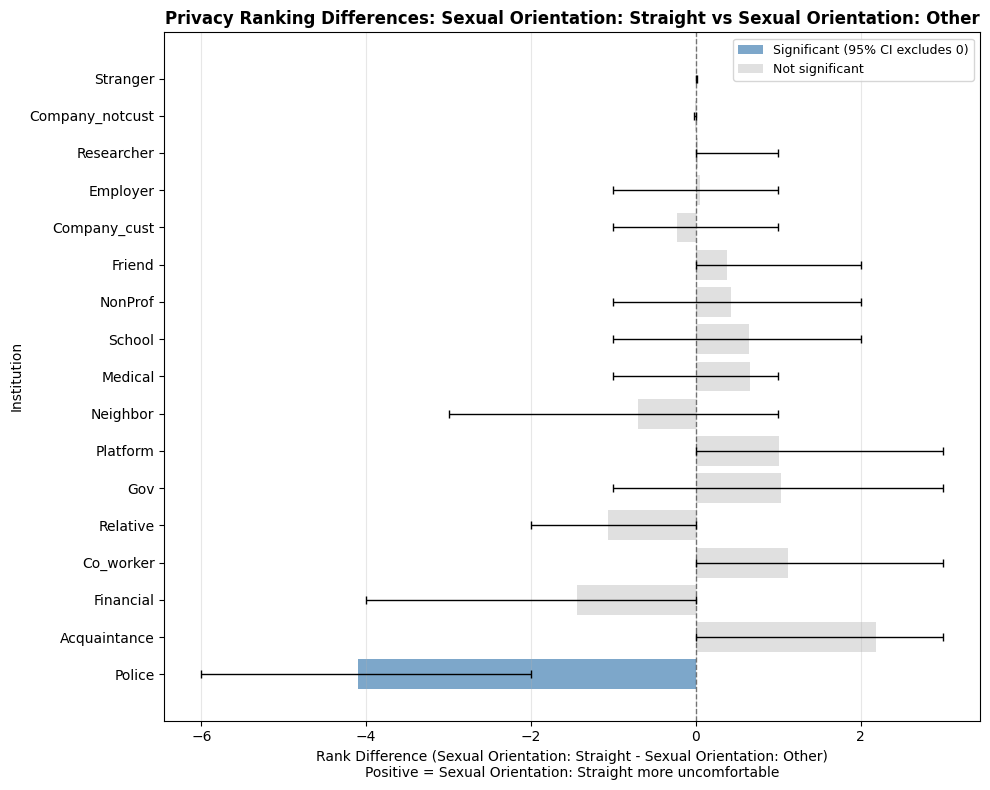

In [47]:
straightother_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Sexual_Orientation_straight', 'Dem_Sexual_Orientation_other',
    'Sexual Orientation: Straight', 'Sexual Orientation: Other',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. Sexual Orientation: Bi-sexual Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0000      1.0    1.000     5.946602
Company_notcust     2.0000      2.0    2.000     5.468293
Police              3.4094      3.0    5.000     4.830097
Platform            4.3287      3.0    6.000     4.718447
Company_cust        4.3402      3.0    5.000     4.718447
Neighbor            6.5019      5.0    8.000     4.466019
Gov                 6.8759      5.0    9.000     4.436893
Acquaintance        7.5900      6.0    8.000     4.360976
Co_worker           9.5241      8.0   11.000     4.145631
NonProf             9.5534      9.0   10.025     4.140777
Financial          11.1227     10.0   12.000     3.941748
School             11.7888     11.0   13.000     3.868932
Employer           12.9663     12.0   13.000     3.694175
Researcher      

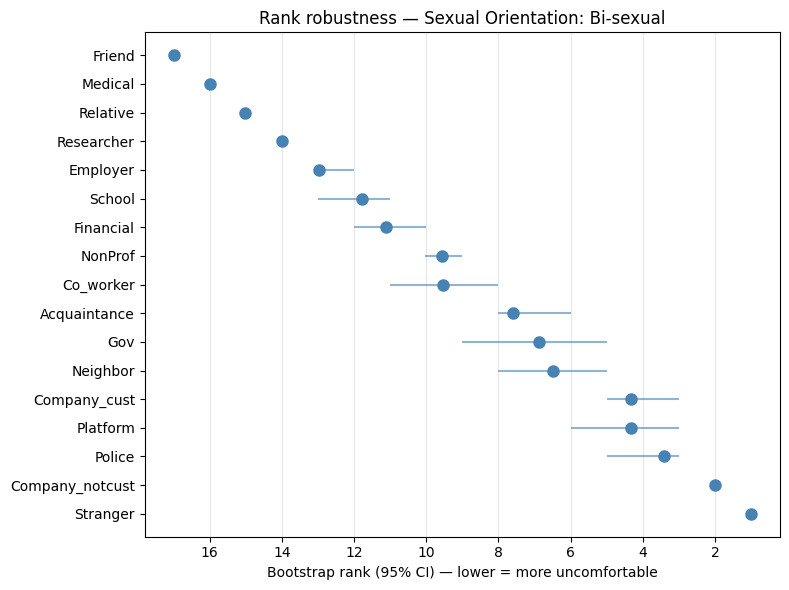

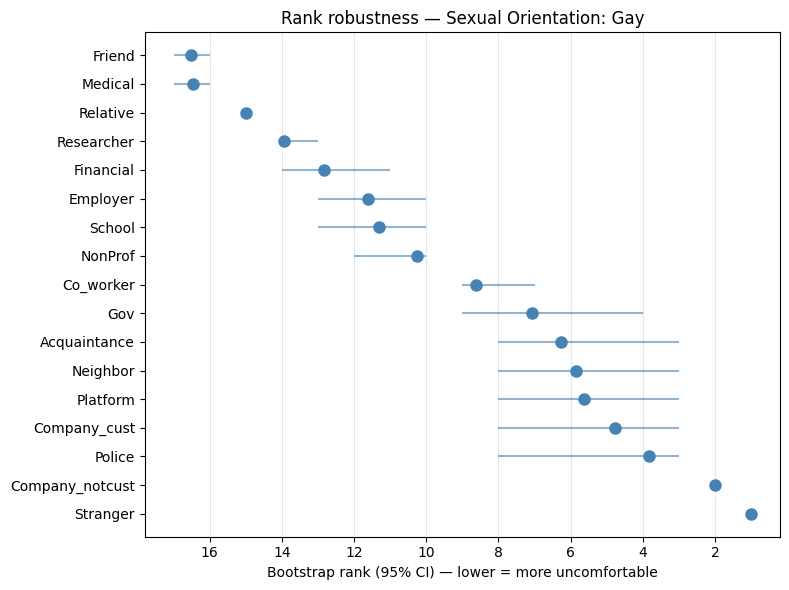

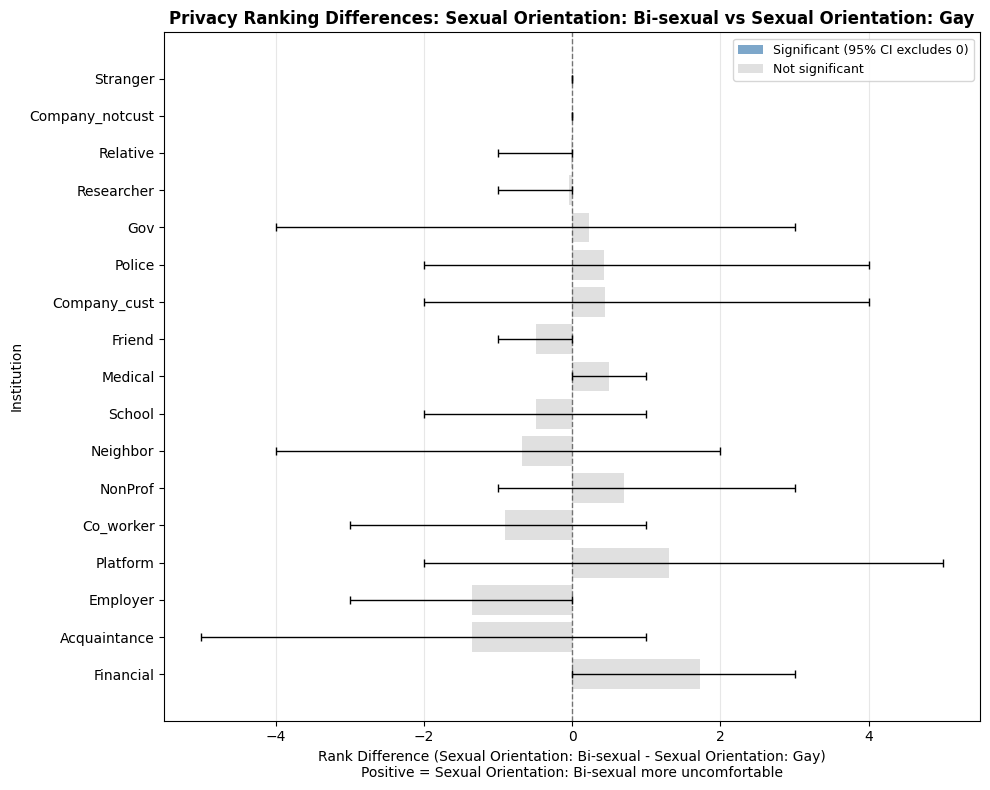

In [48]:
gaybi_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Sexual_Orientation_Bisexual', 'Dem_Sexual_Orientation_Gay',
    'Sexual Orientation: Bi-sexual', 'Sexual Orientation: Gay',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. Sexual Orientation: Bi-sexual Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0000      1.0    1.000     5.946602
Company_notcust     2.0000      2.0    2.000     5.468293
Police              3.4094      3.0    5.000     4.830097
Platform            4.3287      3.0    6.000     4.718447
Company_cust        4.3402      3.0    5.000     4.718447
Neighbor            6.5019      5.0    8.000     4.466019
Gov                 6.8759      5.0    9.000     4.436893
Acquaintance        7.5900      6.0    8.000     4.360976
Co_worker           9.5241      8.0   11.000     4.145631
NonProf             9.5534      9.0   10.025     4.140777
Financial          11.1227     10.0   12.000     3.941748
School             11.7888     11.0   13.000     3.868932
Employer           12.9663     12.0   13.000     3.694175
Researcher      

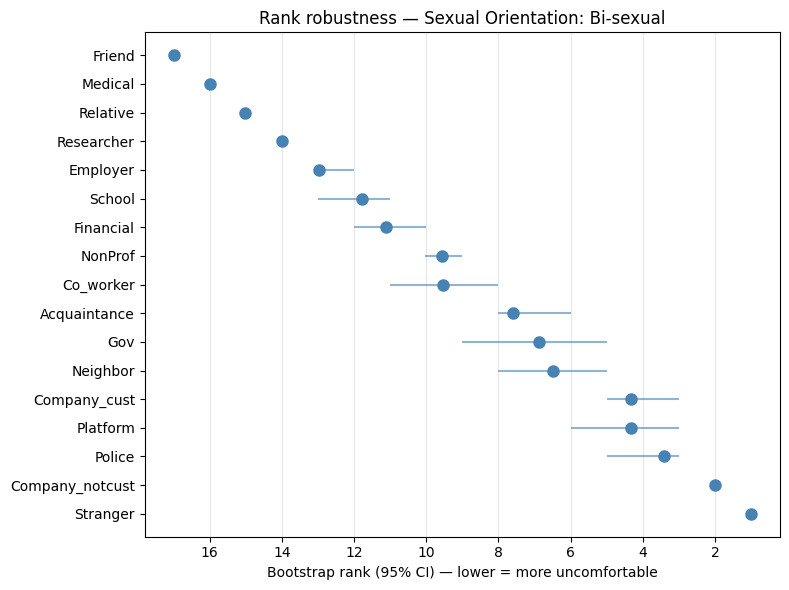

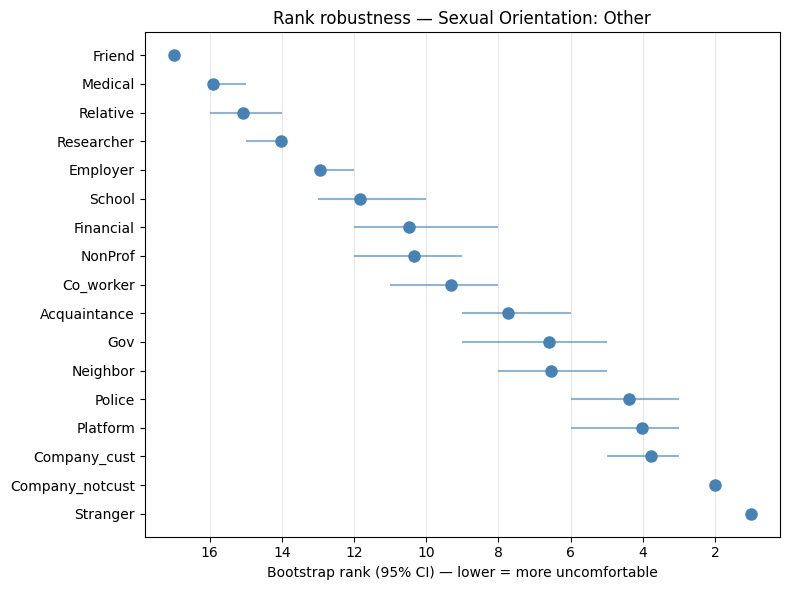

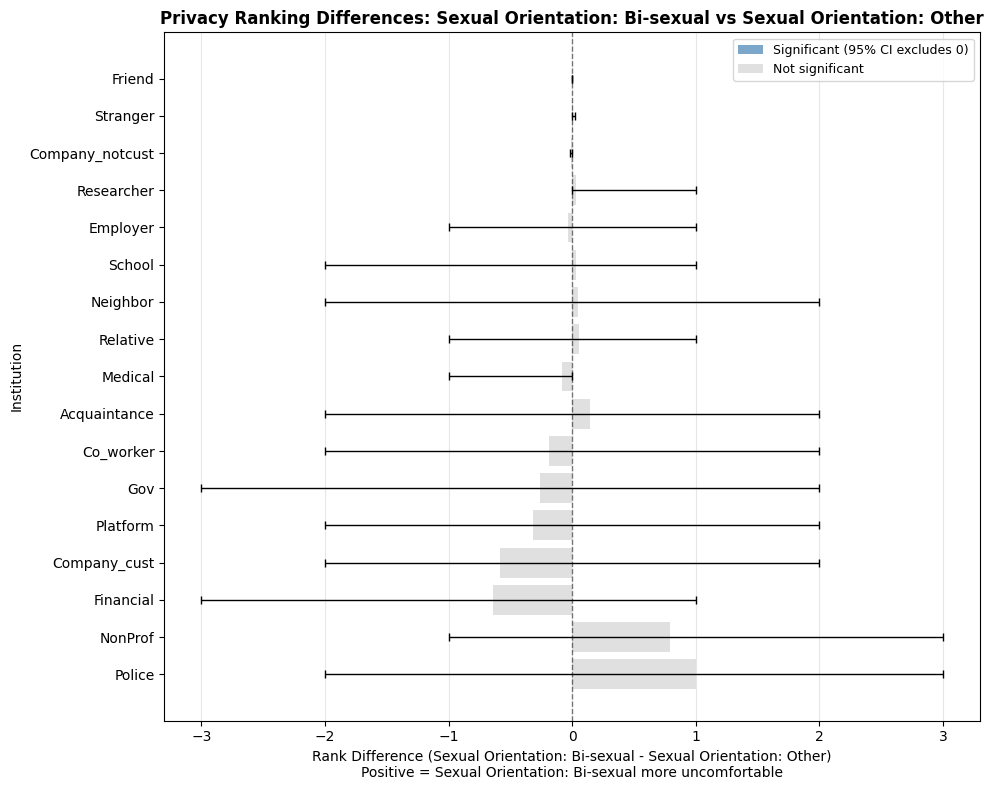

In [49]:
otherbi_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'Dem_Sexual_Orientation_Bisexual', 'Dem_Sexual_Orientation_other',
    'Sexual Orientation: Bi-sexual', 'Sexual Orientation: Other',
    output_dir=output_dir,
    n_bootstrap=10000
)


1. ACES Yes Rankings
----------------------------------------------------------------------
                 rank_mean  rank_lo  rank_hi  actual_mean
institution                                              
Stranger            1.0000      1.0      1.0     5.901546
Company_notcust     2.0000      2.0      2.0     5.438925
Platform            3.0156      3.0      3.0     4.778682
Company_cust        4.0545      4.0      5.0     4.695688
Police              4.9301      4.0      5.0     4.616639
Gov                 6.1347      6.0      7.0     4.472742
Acquaintance        6.8832      6.0      7.0     4.411717
Neighbor            7.9820      8.0      8.0     4.336585
Co_worker           9.0095      9.0      9.0     4.206672
NonProf             9.9904     10.0     10.0     4.113100
Financial          11.4216     11.0     12.0     3.866558
School             11.5784     11.0     12.0     3.858537
Employer           13.0000     13.0     13.0     3.674532
Researcher         14.0000     14.0  

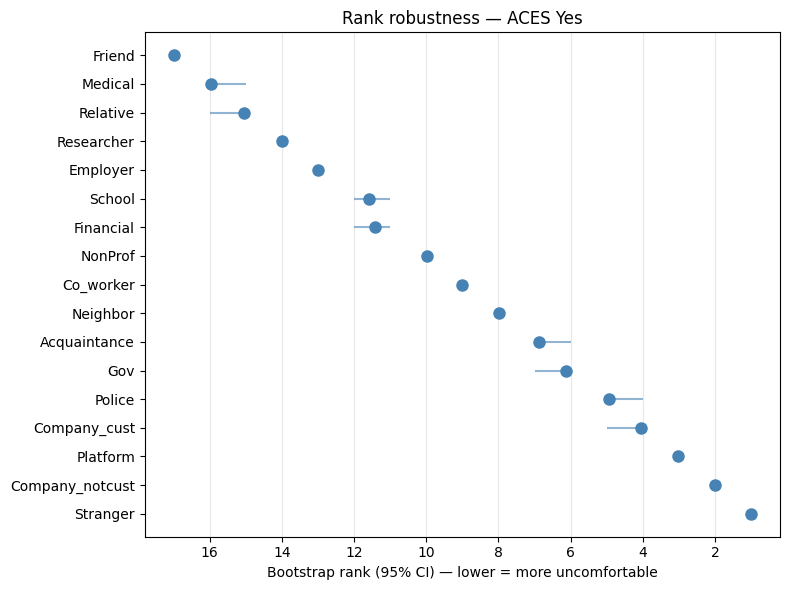

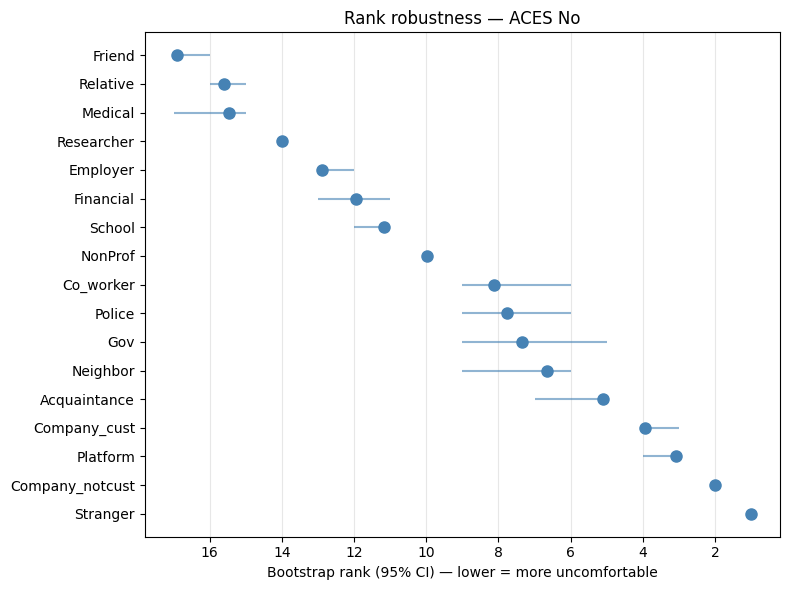

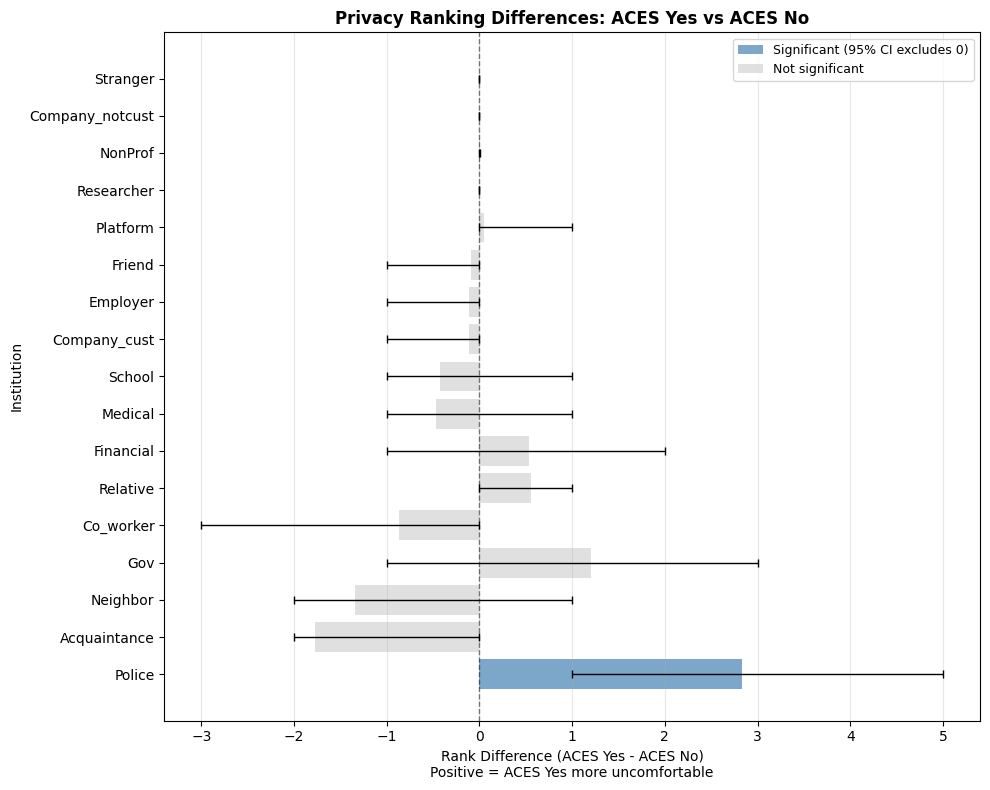

In [51]:
acesyesno_results = analyze_demographic_pair(
    df_all, CONTEXTS,
    'ACES_Yes', 'ACES_No',
    'ACES Yes', 'ACES No',
    output_dir=output_dir,
    n_bootstrap=10000
)